<a href="https://colab.research.google.com/github/erralorenzo/Courses-Kag/blob/main/Intermediate_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Course Summary

This notebook is a comprehensive guide to **Intermediate Machine Learning**, focusing on techniques to improve model performance and handle real-world data challenges:

1.  **Missing Values:** Learning three approaches to deal with incomplete datasets: dropping columns, imputation, and tracking imputed values.
2.  **Categorical Variables:** Handling non-numeric data using techniques like Ordinal Encoding and One-Hot Encoding.
3.  **Pipelines:** Bundling preprocessing and modeling steps to create cleaner, more reliable, and easily deployable code.
4.  **Cross-Validation:** Using multiple subsets of data to get a more robust measure of model performance, especially on smaller datasets.
5.  **XGBoost:** Implementing Gradient Boosting, one of the most powerful and popular algorithms for structured data competitions.
6.  **Data Leakage:** Identifying and preventing subtle errors where information from the target 'leaks' into the training process, ruining real-world reliability.

### Credits & Resources

The following resources from Kaggle Learn are the primary sources and credits for this content:

*   **Course Home:** [Kaggle - Intermediate Machine Learning](https://www.kaggle.com/learn/intermediate-machine-learning)

# 1 Introduction

Review what you need for this course.

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

home_data_for_ml_course_path = kagglehub.competition_download('home-data-for-ml-course')
dansbecker_aer_credit_card_data_path = kagglehub.dataset_download('dansbecker/aer-credit-card-data')
dansbecker_melbourne_housing_snapshot_path = kagglehub.dataset_download('dansbecker/melbourne-housing-snapshot')

print('Data source import complete.')


## Introduction

Welcome to Kaggle's **Intermediate Machine Learning** course!

If you have some background in machine learning and you'd like to learn how to quickly improve the quality of your models, you're in the right place!  In this course, you will accelerate your machine learning expertise by learning how to:
- tackle data types often found in real-world datasets (**missing values**, **categorical variables**),
- design **pipelines** to improve the quality of your machine learning code,
- use advanced techniques for model validation (**cross-validation**),
- build state-of-the-art models that are widely used to win Kaggle competitions (**XGBoost**), and
- avoid common and important data science mistakes (**leakage**).

Along the way, you'll apply your knowledge by completing a hands-on exercise with real-world data for each new topic.  The hands-on exercises use data from the [Housing Prices Competition for Kaggle Learn Users](https://www.kaggle.com/c/home-data-for-ml-course), where you'll use 79 different explanatory variables (such as the type of roof, number of bedrooms, and number of bathrooms) to predict home prices.  You'll measure your progress by submitting predictions to this competition and watching your position rise on [the leaderboard](https://www.kaggle.com/c/home-data-for-ml-course/leaderboard)!

![tut1_competition](https://storage.googleapis.com/kaggle-competitions/kaggle/5407/media/housesbanner.png)

# Prerequisites

You're ready for this course if you've built a machine learning model before, and you're familiar with topics such as [model validation](https://www.kaggle.com/dansbecker/model-validation), [underfitting and overfitting](https://www.kaggle.com/dansbecker/underfitting-and-overfitting), and [random forests](https://www.kaggle.com/dansbecker/random-forests).  

If you're completely new to machine learning, please check out our [Intro to Machine Learning course](https://www.kaggle.com/learn/intro-to-machine-learning), which covers everything you need to prepare for this course.


# 1 Ex Introduction



In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

home_data_for_ml_course_path = kagglehub.competition_download('home-data-for-ml-course')

print('Data source import complete.')


As a warm-up, you'll review some machine learning fundamentals and submit your initial results to a Kaggle competition.

## Setup

The questions below will give you feedback on your work. Run the following cell to set up the feedback system.

In [ ]:
# Set up code checking
import os
if not os.path.exists("../input/train.csv"):
    os.symlink("../input/home-data-for-ml-course/train.csv", "../input/train.csv")
    os.symlink("../input/home-data-for-ml-course/test.csv", "../input/test.csv")
from learntools.core import binder
binder.bind(globals())
from learntools.ml_intermediate.ex1 import *
print("Setup Complete")

Setup Complete


You will work with data from the [Housing Prices Competition for Kaggle Learn Users](https://www.kaggle.com/c/home-data-for-ml-course) to predict home prices in Iowa using 79 explanatory variables describing (almost) every aspect of the homes.  

![Ames Housing dataset image](https://storage.googleapis.com/kaggle-media/learn/images/lTJVG4e.png)

Run the next code cell without changes to load the training and validation features in `X_train` and `X_valid`, along with the prediction targets in `y_train` and `y_valid`.  The test features are loaded in `X_test`.  (_If you need to review **features** and **prediction targets**, please check out [this short tutorial](https://www.kaggle.com/dansbecker/your-first-machine-learning-model).  To read about model **validation**, look [here](https://www.kaggle.com/dansbecker/model-validation).  Alternatively, if you'd prefer to look through a full course to review all of these topics, start [here](https://www.kaggle.com/learn/machine-learning).)_

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Read the data
X_full = pd.read_csv('../input/train.csv', index_col='Id')
X_test_full = pd.read_csv('../input/test.csv', index_col='Id')

# Obtain target and predictors
y = X_full.SalePrice
features = ['LotArea', 'YearBuilt', '1stFlrSF', '2ndFlrSF', 'FullBath', 'BedroomAbvGr', 'TotRmsAbvGrd']
X = X_full[features].copy()
X_test = X_test_full[features].copy()

# Break off validation set from training data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2,
                                                      random_state=0)

Use the next cell to print the first several rows of the data. It's a nice way to get an overview of the data you will use in your price prediction model.

In [ ]:
X_train.head()

,LotArea,YearBuilt,1stFlrSF,2ndFlrSF,FullBath,BedroomAbvGr,TotRmsAbvGrd
Id,,,,,,,
619,11694,2007,1828,0,2,3,9
871,6600,1962,894,0,1,2,5
93,13360,1921,964,0,1,2,5
818,13265,2002,1689,0,2,3,7
303,13704,2001,1541,0,2,3,6


The next code cell defines five different random forest models.  Run this code cell without changes.  (_To review **random forests**, look [here](https://www.kaggle.com/dansbecker/random-forests)._)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Define the models
model_1 = RandomForestRegressor(n_estimators=50, random_state=0)
model_2 = RandomForestRegressor(n_estimators=100, random_state=0)
model_3 = RandomForestRegressor(n_estimators=100, criterion='absolute_error', random_state=0)
model_4 = RandomForestRegressor(n_estimators=200, min_samples_split=20, random_state=0)
model_5 = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=0)

models = [model_1, model_2, model_3, model_4, model_5]

To select the best model out of the five, we define a function `score_model()` below.  This function returns the mean absolute error (MAE) from the validation set.  Recall that the best model will obtain the lowest MAE.  (_To review **mean absolute error**, look [here](https://www.kaggle.com/dansbecker/model-validation).)_

Run the code cell without changes.

In [ ]:
from sklearn.metrics import mean_absolute_error

# Function for comparing different models
def score_model(model, X_t=X_train, X_v=X_valid, y_t=y_train, y_v=y_valid):
    model.fit(X_t, y_t)
    preds = model.predict(X_v)
    return mean_absolute_error(y_v, preds)

for i in range(0, len(models)):
    mae = score_model(models[i])
    print("Model %d MAE: %d" % (i+1, mae))

Model 1 MAE: 24015
Model 2 MAE: 23740
Model 3 MAE: 23528
Model 4 MAE: 23996
Model 5 MAE: 23706


## Step 1: Evaluate several models

Use the above results to fill in the line below.  Which model is the best model?  Your answer should be one of `model_1`, `model_2`, `model_3`, `model_4`, or `model_5`.

In [ ]:
# Fill in the best model
best_model = model_3

# Check your answer
step_1.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

## Step 2: Generate test predictions

Great. You know how to evaluate what makes an accurate model. Now it's time to go through the modeling process and make predictions. In the line below, create a Random Forest model with the variable name `my_model`.

In [ ]:
# Define a model
my_model = model_3 = RandomForestRegressor(n_estimators=100, criterion='absolute_error', random_state=0)


# Check your answer
step_2.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
#step_2.hint()
#step_2.solution()

Run the next code cell without changes.  The code fits the model to the training and validation data, and then generates test predictions that are saved to a CSV file.  These test predictions can be submitted directly to the competition!

In [ ]:
# Fit the model to the training data
my_model.fit(X, y)

# Generate test predictions
preds_test = my_model.predict(X_test)

# Save predictions in format used for competition scoring
output = pd.DataFrame({'Id': X_test.index,
                       'SalePrice': preds_test})
print(output)
output.to_csv('submission.csv', index=False)

        Id  SalePrice
0     1461  119433.08
1     1462  158367.50
2     1463  185351.21
3     1464  178343.12
4     1465  192898.29
...    ...        ...
1454  2915   86155.00
1455  2916   89050.00
1456  2917  156296.92
1457  2918  132232.50
1458  2919  230870.60

[1459 rows x 2 columns]


## Submit your results

Once you have successfully completed Step 2, you're ready to submit your results to the leaderboard!  First, you'll need to join the competition if you haven't already.  So open a new window by clicking on [this link](https://www.kaggle.com/c/home-data-for-ml-course).  Then click on the **Join Competition** button.  _(If you see a "Submit Predictions" button instead of a "Join Competition" button, you have already joined the competition, and don't need to do so again.)_

Next, follow the instructions below:
1. Begin by clicking on the **Save Version** button in the top right corner of the window.  This will generate a pop-up window.  
2. Ensure that the **Save and Run All** option is selected, and then click on the **Save** button.
3. This generates a window in the bottom left corner of the notebook.  After it has finished running, click on the number to the right of the **Save Version** button.  This pulls up a list of versions on the right of the screen.  Click on the ellipsis **(...)** to the right of the most recent version, and select **Open in Viewer**.  This brings you into view mode of the same page. You will need to scroll down to get back to these instructions.
4. Click on the **Data** tab near the top of the screen.  Then, click on the file you would like to submit, and click on the **Submit** button to submit your results to the leaderboard.

You have now successfully submitted to the competition!

If you want to keep working to improve your performance, select the **Edit** button in the top right of the screen. Then you can change your code and repeat the process. There's a lot of room to improve, and you will climb up the leaderboard as you work.



#2 Missing Values

Missing values happen. Be prepared for this common challenge in real datasets.


In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

home_data_for_ml_course_path = kagglehub.competition_download('home-data-for-ml-course')
dansbecker_aer_credit_card_data_path = kagglehub.dataset_download('dansbecker/aer-credit-card-data')
dansbecker_melbourne_housing_snapshot_path = kagglehub.dataset_download('dansbecker/melbourne-housing-snapshot')

print('Data source import complete.')


In this tutorial, you will learn three approaches to **dealing with missing values**. Then you'll compare the effectiveness of these approaches on a real-world dataset.

## Introduction

There are many ways data can end up with missing values. For example,
- A 2 bedroom house won't include a value for the size of a third bedroom.
- A survey respondent may choose not to share his income.

Most machine learning libraries (including scikit-learn) give an error if you try to build a model using data with missing values. So you'll need to choose one of the strategies below.

## Three Approaches


### 1) A Simple Option: Drop Columns with Missing Values

The simplest option is to drop columns with missing values.

![tut2_approach1](https://storage.googleapis.com/kaggle-media/learn/images/Sax80za.png)

Unless most values in the dropped columns are missing, the model loses access to a lot of (potentially useful!) information with this approach.  As an extreme example, consider a dataset with 10,000 rows, where one important column is missing a single entry. This approach would drop the column entirely!

### 2) A Better Option: Imputation

**Imputation** fills in the missing values with some number.  For instance, we can fill in the mean value along each column.

![tut2_approach2](https://storage.googleapis.com/kaggle-media/learn/images/4BpnlPA.png)

The imputed value won't be exactly right in most cases, but it usually leads to more accurate models than you would get from dropping the column entirely.

### 3) An Extension To Imputation

Imputation is the standard approach, and it usually works well. However, imputed values may be systematically above or below their actual values (which weren't collected in the dataset). Or rows with missing values may be unique in some other way. In that case, your model would make better predictions by considering which values were originally missing.  

![tut3_approach3](https://storage.googleapis.com/kaggle-media/learn/images/UWOyg4a.png)

In this approach, we impute the missing values, as before.  And, additionally, for each column with missing entries in the original dataset, we add a new column that shows the location of the imputed entries.

In some cases, this will meaningfully improve results. In other cases, it doesn't help at all.

# Example

In the example, we will work with the [Melbourne Housing dataset](https://www.kaggle.com/dansbecker/melbourne-housing-snapshot/home).  Our model will use information such as the number of rooms and land size to predict home price.

We won't focus on the data loading step. Instead, you can imagine you are at a point where you already have the training and validation data in `X_train`, `X_valid`, `y_train`, and `y_valid`.

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split

# Load the data
data = pd.read_csv('../input/melbourne-housing-snapshot/melb_data.csv')

# Select target
y = data.Price

# To keep things simple, we'll use only numerical predictors
melb_predictors = data.drop(['Price'], axis=1)
X = melb_predictors.select_dtypes(exclude=['object'])

# Divide data into training and validation subsets
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2,
                                                      random_state=0)

### Define Function to Measure Quality of Each Approach

We define a function `score_dataset()` to compare different approaches to dealing with missing values. This function reports the [mean absolute error](https://en.wikipedia.org/wiki/Mean_absolute_error) (MAE) from a random forest model.

In [ ]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Function for comparing different approaches
def score_dataset(X_train, X_valid, y_train, y_valid):
    model = RandomForestRegressor(n_estimators=10, random_state=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    return mean_absolute_error(y_valid, preds)

### Score from Approach 1 (Drop Columns with Missing Values)

Since we are working with both training and validation sets, we are careful to drop the same columns in both DataFrames.  

In [ ]:
# Get names of columns with missing values
cols_with_missing = [col for col in X_train.columns
                     if X_train[col].isnull().any()]

# Drop columns in training and validation data
reduced_X_train = X_train.drop(cols_with_missing, axis=1)
reduced_X_valid = X_valid.drop(cols_with_missing, axis=1)

print("MAE from Approach 1 (Drop columns with missing values):")
print(score_dataset(reduced_X_train, reduced_X_valid, y_train, y_valid))

### Score from Approach 2 (Imputation)

Next, we use [`SimpleImputer`](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) to replace missing values with the mean value along each column.

Although it's simple, filling in the mean value generally performs quite well (but this varies by dataset).  While statisticians have experimented with more complex ways to determine imputed values (such as **regression imputation**, for instance), the complex strategies typically give no additional benefit once you plug the results into sophisticated machine learning models.

In [ ]:
from sklearn.impute import SimpleImputer

# Imputation
my_imputer = SimpleImputer()
imputed_X_train = pd.DataFrame(my_imputer.fit_transform(X_train))
imputed_X_valid = pd.DataFrame(my_imputer.transform(X_valid))

# Imputation removed column names; put them back
imputed_X_train.columns = X_train.columns
imputed_X_valid.columns = X_valid.columns

print("MAE from Approach 2 (Imputation):")
print(score_dataset(imputed_X_train, imputed_X_valid, y_train, y_valid))

We see that **Approach 2** has lower MAE than **Approach 1**, so **Approach 2** performed better on this dataset.

### Score from Approach 3 (An Extension to Imputation)

Next, we impute the missing values, while also keeping track of which values were imputed.

In [ ]:
# Make copy to avoid changing original data (when imputing)
X_train_plus = X_train.copy()
X_valid_plus = X_valid.copy()

# Make new columns indicating what will be imputed
for col in cols_with_missing:
    X_train_plus[col + '_was_missing'] = X_train_plus[col].isnull()
    X_valid_plus[col + '_was_missing'] = X_valid_plus[col].isnull()

# Imputation
my_imputer = SimpleImputer()
imputed_X_train_plus = pd.DataFrame(my_imputer.fit_transform(X_train_plus))
imputed_X_valid_plus = pd.DataFrame(my_imputer.transform(X_valid_plus))

# Imputation removed column names; put them back
imputed_X_train_plus.columns = X_train_plus.columns
imputed_X_valid_plus.columns = X_valid_plus.columns

print("MAE from Approach 3 (An Extension to Imputation):")
print(score_dataset(imputed_X_train_plus, imputed_X_valid_plus, y_train, y_valid))

As we can see, **Approach 3** performed slightly worse than **Approach 2**.

### So, why did imputation perform better than dropping the columns?

The training data has 10864 rows and 12 columns, where three columns contain missing data.  For each column, less than half of the entries are missing.  Thus, dropping the columns removes a lot of useful information, and so it makes sense that imputation would perform better.

In [ ]:
# Shape of training data (num_rows, num_columns)
print(X_train.shape)

# Number of missing values in each column of training data
missing_val_count_by_column = (X_train.isnull().sum())
print(missing_val_count_by_column[missing_val_count_by_column > 0])

## Conclusion
As is common, imputing missing values (in **Approach 2** and **Approach 3**) yielded better results, relative to when we simply dropped columns with missing values (in **Approach 1**).

# Your Turn

Compare these approaches to dealing with missing values yourself in **[this exercise](https://www.kaggle.com/kernels/fork/3370280)**!


# 2 Ex Missing Values

Missing values happen. Be prepared for this common challenge in real datasets.


In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

home_data_for_ml_course_path = kagglehub.competition_download('home-data-for-ml-course')

print('Data source import complete.')


Now it's your turn to test your new knowledge of **missing values** handling. You'll probably find it makes a big difference.

## Setup

The questions will give you feedback on your work. Run the following cell to set up the feedback system.

In [ ]:
# Set up code checking
import os
if not os.path.exists("../input/train.csv"):
    os.symlink("../input/home-data-for-ml-course/train.csv", "../input/train.csv")
    os.symlink("../input/home-data-for-ml-course/test.csv", "../input/test.csv")
from learntools.core import binder
binder.bind(globals())
from learntools.ml_intermediate.ex2 import *
print("Setup Complete")

Setup Complete


In this exercise, you will work with data from the [Housing Prices Competition for Kaggle Learn Users](https://www.kaggle.com/c/home-data-for-ml-course).

![Ames Housing dataset image](https://storage.googleapis.com/kaggle-media/learn/images/lTJVG4e.png)

Run the next code cell without changes to load the training and validation sets in `X_train`, `X_valid`, `y_train`, and `y_valid`.  The test set is loaded in `X_test`.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Read the data
X_full = pd.read_csv('../input/train.csv', index_col='Id')
X_test_full = pd.read_csv('../input/test.csv', index_col='Id')

# Remove rows with missing target, separate target from predictors
X_full.dropna(axis=0, subset=['SalePrice'], inplace=True)
y = X_full.SalePrice
X_full.drop(['SalePrice'], axis=1, inplace=True)

# To keep things simple, we'll use only numerical predictors
X = X_full.select_dtypes(exclude=['object'])
X_test = X_test_full.select_dtypes(exclude=['object'])

# Break off validation set from training data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2,
                                                      random_state=0)

Use the next code cell to print the first five rows of the data.

In [ ]:
X_train.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
Id,,,,,,,,,,,,,,,,,,,,,
619,20,90.0,11694,9,5,2007,2007,452.0,48,0,...,774,0,108,0,0,260,0,0,7,2007
871,20,60.0,6600,5,5,1962,1962,0.0,0,0,...,308,0,0,0,0,0,0,0,8,2009
93,30,80.0,13360,5,7,1921,2006,0.0,713,0,...,432,0,0,44,0,0,0,0,8,2009
818,20,NaN,13265,8,5,2002,2002,148.0,1218,0,...,857,150,59,0,0,0,0,0,7,2008
303,20,118.0,13704,7,5,2001,2002,150.0,0,0,...,843,468,81,0,0,0,0,0,1,2006


You can already see a few missing values in the first several rows.  In the next step, you'll obtain a more comprehensive understanding of the missing values in the dataset.

## Step 1: Preliminary investigation

Run the code cell below without changes.

In [ ]:
# Shape of training data (num_rows, num_columns)
print(X_train.shape)

# Number of missing values in each column of training data
missing_val_count_by_column = (X_train.isnull().sum())
print(missing_val_count_by_column[missing_val_count_by_column > 0])

(1168, 36)
LotFrontage    212
MasVnrArea       6
GarageYrBlt     58
dtype: int64


### Part A

Use the above output to answer the questions below.

In [ ]:
# Fill in the line below: How many rows are in the training data?
num_rows = 1168

# Fill in the line below: How many columns in the training data
# have missing values?
num_cols_with_missing = 3

# Fill in the line below: How many missing entries are contained in
# all of the training data?
tot_missing = 212+6+58

# Check your answers
step_1.a.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
#step_1.a.hint()
#step_1.a.solution()

### Part B
Considering your answers above, what do you think is likely the best approach to dealing with the missing values?

In [ ]:
# Check your answer (Run this code cell to receive credit!)
step_1.b.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 

Since there are relatively few missing entries in the data (the column with the greatest percentage of missing values is missing less than 20% of its entries), we can expect that dropping columns is unlikely to yield good results.  This is because we'd be throwing away a lot of valuable data, and so imputation will likely perform better.

Correct:

Since there are relatively few missing entries in the data (the column with the greatest percentage of missing values is missing less than 20% of its entries), we can expect that dropping columns is unlikely to yield good results. This is because we'd be throwing away a lot of valuable data, and so imputation will likely perform better.

In [ ]:
#step_1.b.hint()

To compare different approaches to dealing with missing values, you'll use the same `score_dataset()` function from the tutorial.  This function reports the [mean absolute error](https://en.wikipedia.org/wiki/Mean_absolute_error) (MAE) from a random forest model.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Function for comparing different approaches
def score_dataset(X_train, X_valid, y_train, y_valid):
    model = RandomForestRegressor(n_estimators=100, random_state=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    return mean_absolute_error(y_valid, preds)

## Step 2: Drop columns with missing values

In this step, you'll preprocess the data in `X_train` and `X_valid` to remove columns with missing values.  Set the preprocessed DataFrames to `reduced_X_train` and `reduced_X_valid`, respectively.  

In [ ]:
# Fill in the line below: get names of columns with missing values
cols_with_missing = [col for col in X_train.columns if X_train[col].isnull().any()]

# Fill in the lines below: drop columns in training and validation data
reduced_X_train = X_train.drop(cols_with_missing, axis=1)
reduced_X_valid = X_valid.drop(cols_with_missing, axis=1)

# Check your answers
step_2.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
step_2.hint()
#step_2.solution()

<IPython.core.display.Javascript object>

<span style="color:#3366cc">Hint:</span> Begin by finding the list of columns in the data with missing values.  Then, drop these columns in both the training and validation data with the `drop()` method.

Run the next code cell without changes to obtain the MAE for this approach.

In [ ]:
print("MAE (Drop columns with missing values):")
print(score_dataset(reduced_X_train, reduced_X_valid, y_train, y_valid))

MAE (Drop columns with missing values):
17837.82570776256


## Step 3: Imputation

### Part A

Use the next code cell to impute missing values with the mean value along each column.  Set the preprocessed DataFrames to `imputed_X_train` and `imputed_X_valid`.  Make sure that the column names match those in `X_train` and `X_valid`.

In [ ]:
from sklearn.impute import SimpleImputer

# Imputation
my_imputer = SimpleImputer()
imputed_X_train = pd.DataFrame(my_imputer.fit_transform(X_train))
imputed_X_valid = pd.DataFrame(my_imputer.transform(X_valid))

# Fill in the lines below: imputation removed column names; put them back
imputed_X_train.columns = X_train.columns
imputed_X_valid.columns = X_valid.columns

# Check your answers
step_3.a.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Read the data
X_full = pd.read_csv('../input/train.csv', index_col='Id')
X_test_full = pd.read_csv('../input/test.csv', index_col='Id')

# Remove rows with missing target, separate target from predictors
X_full.dropna(axis=0, subset=['SalePrice'], inplace=True)
y = X_full.SalePrice
X_full.drop(['SalePrice'], axis=1, inplace=True)

# To keep things simple, we'll use only numerical predictors
X = X_full.select_dtypes(exclude=['object'])
X_test = X_test_full.select_dtypes(exclude=['object'])

# Break off validation set from training data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2,
                                                      random_state=0)

In [ ]:
# Lines below will give you a hint or solution code
#step_3.a.hint()
#step_3.a.solution()

Run the next code cell without changes to obtain the MAE for this approach.

In [ ]:
print("MAE (Imputation):")
print(score_dataset(imputed_X_train, imputed_X_valid, y_train, y_valid))

MAE (Imputation):
18062.894611872147


### Part B

Compare the MAE from each approach.  Does anything surprise you about the results?  Why do you think one approach performed better than the other?

In [ ]:
# Check your answer (Run this code cell to receive credit!)
step_3.b.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 

Given that thre are so few missing values in the dataset, we'd expect imputation to perform better than dropping columns entirely.  However, we see that dropping columns performs slightly better!  While this can probably partially be attributed to noise in the dataset, another potential explanation is that the imputation method is not a great match to this dataset.  That is, maybe instead of filling in the mean value, it makes more sense to set every missing value to a value of 0, to fill in the most frequently encountered value, or to use some other method.  For instance, consider the `GarageYrBlt` column (which indicates the year that the garage was built).  It's likely that in some cases, a missing value could indicate a house that does not have a garage.  Does it make more sense to fill in the median value along each column in this case?  Or could we get better results by filling in the minimum value along each column?  It's not quite clear what's best in this case, but perhaps we can rule out some options immediately - for instance, setting missing values in this column to 0 is likely to yield horrible results!

Given that thre are so few missing values in the dataset, we'd expect imputation to perform better than dropping columns entirely. However, we see that dropping columns performs slightly better! While this can probably partially be attributed to noise in the dataset, another potential explanation is that the imputation method is not a great match to this dataset. That is, maybe instead of filling in the mean value, it makes more sense to set every missing value to a value of 0, to fill in the most frequently encountered value, or to use some other method. For instance, consider the GarageYrBlt column (which indicates the year that the garage was built). It's likely that in some cases, a missing value could indicate a house that does not have a garage. Does it make more sense to fill in the median value along each column in this case? Or could we get better results by filling in the minimum value along each column? It's not quite clear what's best in this case, but perhaps we can rule out some options immediately - for instance, setting missing values in this column to 0 is likely to yield horrible results!

## Step 4: Generate test predictions

In this final step, you'll use any approach of your choosing to deal with missing values.  Once you've preprocessed the training and validation features, you'll train and evaluate a random forest model.  Then, you'll preprocess the test data before generating predictions that can be submitted to the competition!

### Part A

Use the next code cell to preprocess the training and validation data.  Set the preprocessed DataFrames to `final_X_train` and `final_X_valid`.  **You can use any approach of your choosing here!**  in order for this step to be marked as correct, you need only ensure:
- the preprocessed DataFrames have the same number of columns,
- the preprocessed DataFrames have no missing values,
- `final_X_train` and `y_train` have the same number of rows, and
- `final_X_valid` and `y_valid` have the same number of rows.

In [ ]:
# Preprocessed training and validation features
# Imputation
final_imputer = SimpleImputer(strategy='median')
final_X_train = pd.DataFrame(final_imputer.fit_transform(X_train))
final_X_valid = pd.DataFrame(final_imputer.transform(X_valid))

# Imputation removed column names; put them back
final_X_train.columns = X_train.columns
final_X_valid.columns = X_valid.columns
# Check your answers
step_4.a.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
step_4.a.hint()
step_4.a.solution()

<IPython.core.display.Javascript object>

<span style="color:#3366cc">Hint:</span> Use any approach of your choosing to deal with missing values in the data.  For inspiration, check out the code from the tutorial!

<IPython.core.display.Javascript object>

<span style="color:#33cc99">Solution:</span> 
```python
# Imputation
final_imputer = SimpleImputer(strategy='median')
final_X_train = pd.DataFrame(final_imputer.fit_transform(X_train))
final_X_valid = pd.DataFrame(final_imputer.transform(X_valid))

# Imputation removed column names; put them back
final_X_train.columns = X_train.columns
final_X_valid.columns = X_valid.columns

```

Run the next code cell to train and evaluate a random forest model.  (*Note that we don't use the `score_dataset()` function above, because we will soon use the trained model to generate test predictions!*)

## Define and fit model
model = RandomForestRegressor(n_estimators=100, random_state=0)
model.fit(final_X_train, y_train)

# Get validation predictions and MAE
preds_valid = model.predict(final_X_valid)
print("MAE (Your approach):")
print(mean_absolute_error(y_valid, preds_valid))

### Part B

Use the next code cell to preprocess your test data.  Make sure that you use a method that agrees with how you preprocessed the training and validation data, and set the preprocessed test features to `final_X_test`.

Then, use the preprocessed test features and the trained model to generate test predictions in `preds_test`.

In order for this step to be marked correct, you need only ensure:
- the preprocessed test DataFrame has no missing values, and
- `final_X_test` has the same number of rows as `X_test`.

In [ ]:
# 1. Definir el imputador (si no lo habías hecho)
from sklearn.impute import SimpleImputer
final_imputer = SimpleImputer(strategy='median') # (o la estrategia que te pida el ejercicio)

# 2. Ajustar y transformar los datos de ENTRENAMIENTO primero (esto soluciona el error)
final_X_train = pd.DataFrame(final_imputer.fit_transform(X_train))

# 3. AHORA SÍ: Transformar los datos de prueba
final_X_test = pd.DataFrame(final_imputer.transform(X_test))

# Opcional: devolver los nombres de las columnas a los DataFrames imputados
final_X_train.columns = X_train.columns
final_X_test.columns = X_test.columns

# Obtener predicciones
model = RandomForestRegressor(n_estimators=100, random_state=0)
model.fit(final_X_train, y_train)
preds_test = model.predict(final_X_test)

# Revisar respuestas
step_4.b.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
step_4.b.hint()
step_4.b.solution()

<IPython.core.display.Javascript object>

<span style="color:#3366cc">Hint:</span> After preprocessing the test data, you can get the model's predictions by using `model.predict()`.

<IPython.core.display.Javascript object>

<span style="color:#33cc99">Solution:</span> 
```python
# Preprocess test data
final_X_test = pd.DataFrame(final_imputer.transform(X_test))

# Get test predictions
preds_test = model.predict(final_X_test)

```

Run the next code cell without changes to save your results to a CSV file that can be submitted directly to the competition.

In [ ]:
# Save test predictions to file
output = pd.DataFrame({'Id': X_test.index,
                       'SalePrice': preds_test})
print(output)
output.to_csv('submission.csv', index=False)

        Id  SalePrice
0     1461  125985.50
1     1462  154599.50
2     1463  180070.24
3     1464  183544.50
4     1465  197549.92
...    ...        ...
1454  2915   87437.12
1455  2916   86994.50
1456  2917  154751.44
1457  2918  107387.00
1458  2919  229281.55

[1459 rows x 2 columns]



# 3 Categorical Variables

There's a lot of non-numeric data out there. Here's how to use it for machine learning.


In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

home_data_for_ml_course_path = kagglehub.competition_download('home-data-for-ml-course')
dansbecker_aer_credit_card_data_path = kagglehub.dataset_download('dansbecker/aer-credit-card-data')
dansbecker_melbourne_housing_snapshot_path = kagglehub.dataset_download('dansbecker/melbourne-housing-snapshot')

print('Data source import complete.')


In this tutorial, you will learn what a **categorical variable** is, along with three approaches for handling this type of data.


## Introduction

A **categorical variable** takes only a limited number of values.  

- Consider a survey that asks how often you eat breakfast and provides four options: "Never", "Rarely", "Most days", or "Every day".  In this case, the data is categorical, because responses fall into a fixed set of categories.
- If people responded to a survey about which what brand of car they owned, the responses would fall into categories like "Honda", "Toyota", and "Ford".  In this case, the data is also categorical.

You will get an error if you try to plug these variables into most machine learning models in Python without preprocessing them first.  In this tutorial, we'll compare three approaches that you can use to prepare your categorical data.

# Three Approaches

### 1) Drop Categorical Variables

The easiest approach to dealing with categorical variables is to simply remove them from the dataset.  This approach will only work well if the columns did not contain useful information.

### 2) Ordinal Encoding

**Ordinal encoding** assigns each unique value to a different integer.

![tut3_ordinalencode](https://storage.googleapis.com/kaggle-media/learn/images/tEogUAr.png)

This approach assumes an ordering of the categories: "Never" (0) < "Rarely" (1) < "Most days" (2) < "Every day" (3).

This assumption makes sense in this example, because there is an indisputable ranking to the categories.  Not all categorical variables have a clear ordering in the values, but we refer to those that do as **ordinal variables**.  For tree-based models (like decision trees and random forests), you can expect ordinal encoding to work well with ordinal variables.

### 3) One-Hot Encoding

**One-hot encoding** creates new columns indicating the presence (or absence) of each possible value in the original data.  To understand this, we'll work through an example.

![tut3_onehot](https://storage.googleapis.com/kaggle-media/learn/images/TW5m0aJ.png)

In the original dataset, "Color" is a categorical variable with three categories: "Red", "Yellow", and "Green".  The corresponding one-hot encoding contains one column for each possible value, and one row for each row in the original dataset.  Wherever the original value was "Red", we put a 1 in the "Red" column; if the original value was "Yellow", we put a 1 in the "Yellow" column, and so on.  

In contrast to ordinal encoding, one-hot encoding *does not* assume an ordering of the categories.  Thus, you can expect this approach to work particularly well if there is no clear ordering in the categorical data (e.g., "Red" is neither _more_ nor _less_ than "Yellow").  We refer to categorical variables without an intrinsic ranking as **nominal variables**.

One-hot encoding generally does not perform well if the categorical variable takes on a large number of values (i.e., you generally won't use it for variables taking more than 15 different values).

# Example

As in the previous tutorial, we will work with the [Melbourne Housing dataset](https://www.kaggle.com/dansbecker/melbourne-housing-snapshot/home).  

We won't focus on the data loading step. Instead, you can imagine you are at a point where you already have the training and validation data in `X_train`, `X_valid`, `y_train`, and `y_valid`.

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split

# Read the data
data = pd.read_csv('../input/melbourne-housing-snapshot/melb_data.csv')

# Separate target from predictors
y = data.Price
X = data.drop(['Price'], axis=1)

# Divide data into training and validation subsets
X_train_full, X_valid_full, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2,
                                                                random_state=0)

# Drop columns with missing values (simplest approach)
cols_with_missing = [col for col in X_train_full.columns if X_train_full[col].isnull().any()]
X_train_full.drop(cols_with_missing, axis=1, inplace=True)
X_valid_full.drop(cols_with_missing, axis=1, inplace=True)

# "Cardinality" means the number of unique values in a column
# Select categorical columns with relatively low cardinality (convenient but arbitrary)
low_cardinality_cols = [cname for cname in X_train_full.columns if X_train_full[cname].nunique() < 10 and
                        X_train_full[cname].dtype == "object"]

# Select numerical columns
numerical_cols = [cname for cname in X_train_full.columns if X_train_full[cname].dtype in ['int64', 'float64']]

# Keep selected columns only
my_cols = low_cardinality_cols + numerical_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()

We take a peek at the training data with the `head()` method below.

In [ ]:
X_train.head()

Next, we obtain a list of all of the categorical variables in the training data.

We do this by checking the data type (or **dtype**) of each column.  The `object` dtype indicates a column has text (there are other things it could theoretically be, but that's unimportant for our purposes).  For this dataset, the columns with text indicate categorical variables.

In [ ]:
# Get list of categorical variables
s = (X_train.dtypes == 'object')
object_cols = list(s[s].index)

print("Categorical variables:")
print(object_cols)

### Define Function to Measure Quality of Each Approach

We define a function `score_dataset()` to compare the three different approaches to dealing with categorical variables. This function reports the [mean absolute error](https://en.wikipedia.org/wiki/Mean_absolute_error) (MAE) from a random forest model.  In general, we want the MAE to be as low as possible!

In [ ]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Function for comparing different approaches
def score_dataset(X_train, X_valid, y_train, y_valid):
    model = RandomForestRegressor(n_estimators=100, random_state=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    return mean_absolute_error(y_valid, preds)

### Score from Approach 1 (Drop Categorical Variables)

We drop the `object` columns with the [`select_dtypes()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.select_dtypes.html) method.

In [ ]:
drop_X_train = X_train.select_dtypes(exclude=['object'])
drop_X_valid = X_valid.select_dtypes(exclude=['object'])

print("MAE from Approach 1 (Drop categorical variables):")
print(score_dataset(drop_X_train, drop_X_valid, y_train, y_valid))

### Score from Approach 2 (Ordinal Encoding)

Scikit-learn has a [`OrdinalEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html) class that can be used to get ordinal encodings.  We loop over the categorical variables and apply the ordinal encoder separately to each column.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Make copy to avoid changing original data
label_X_train = X_train.copy()
label_X_valid = X_valid.copy()

# Apply ordinal encoder to each column with categorical data
ordinal_encoder = OrdinalEncoder()
label_X_train[object_cols] = ordinal_encoder.fit_transform(X_train[object_cols])
label_X_valid[object_cols] = ordinal_encoder.transform(X_valid[object_cols])

print("MAE from Approach 2 (Ordinal Encoding):")
print(score_dataset(label_X_train, label_X_valid, y_train, y_valid))

In the code cell above, for each column, we randomly assign each unique value to a different integer.  This is a common approach that is simpler than providing custom labels; however, we can expect an additional boost in performance if we provide better-informed labels for all ordinal variables.

### Score from Approach 3 (One-Hot Encoding)

We use the [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) class from scikit-learn to get one-hot encodings.  There are a number of parameters that can be used to customize its behavior.  
- We set `handle_unknown='ignore'` to avoid errors when the validation data contains classes that aren't represented in the training data, and
- setting `sparse=False` ensures that the encoded columns are returned as a numpy array (instead of a sparse matrix).

To use the encoder, we supply only the categorical columns that we want to be one-hot encoded.  For instance, to encode the training data, we supply `X_train[object_cols]`. (`object_cols` in the code cell below is a list of the column names with categorical data, and so `X_train[object_cols]` contains all of the categorical data in the training set.)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# Apply one-hot encoder to each column with categorical data
OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
OH_cols_train = pd.DataFrame(OH_encoder.fit_transform(X_train[object_cols]))
OH_cols_valid = pd.DataFrame(OH_encoder.transform(X_valid[object_cols]))

# One-hot encoding removed index; put it back
OH_cols_train.index = X_train.index
OH_cols_valid.index = X_valid.index

# Remove categorical columns (will replace with one-hot encoding)
num_X_train = X_train.drop(object_cols, axis=1)
num_X_valid = X_valid.drop(object_cols, axis=1)

# Add one-hot encoded columns to numerical features
OH_X_train = pd.concat([num_X_train, OH_cols_train], axis=1)
OH_X_valid = pd.concat([num_X_valid, OH_cols_valid], axis=1)

# Ensure all columns have string type
OH_X_train.columns = OH_X_train.columns.astype(str)
OH_X_valid.columns = OH_X_valid.columns.astype(str)

print("MAE from Approach 3 (One-Hot Encoding):")
print(score_dataset(OH_X_train, OH_X_valid, y_train, y_valid))

## Which approach is best?

In this case, dropping the categorical columns (**Approach 1**) performed worst, since it had the highest MAE score.  As for the other two approaches, since the returned MAE scores are so close in value, there doesn't appear to be any meaningful benefit to one over the other.

In general, one-hot encoding (**Approach 3**) will typically perform best, and dropping the categorical columns (**Approach 1**) typically performs worst, but it varies on a case-by-case basis.

## Conclusion

The world is filled with categorical data. You will be a much more effective data scientist if you know how to use this common data type!


# 3 Ex Categorical Variables



In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

home_data_for_ml_course_path = kagglehub.competition_download('home-data-for-ml-course')

print('Data source import complete.')


**This notebook is an exercise in the [Intermediate Machine Learning](https://www.kaggle.com/learn/intermediate-machine-learning) course.  You can reference the tutorial at [this link](https://www.kaggle.com/alexisbcook/categorical-variables).**

---


By encoding **categorical variables**, you'll obtain your best results thus far!

## Setup

The questions below will give you feedback on your work. Run the following cell to set up the feedback system.

In [ ]:
# Set up code checking
import os
if not os.path.exists("../input/train.csv"):
    os.symlink("../input/home-data-for-ml-course/train.csv", "../input/train.csv")
    os.symlink("../input/home-data-for-ml-course/test.csv", "../input/test.csv")
from learntools.core import binder
binder.bind(globals())
from learntools.ml_intermediate.ex3 import *
print("Setup Complete")

Setup Complete


In this exercise, you will work with data from the [Housing Prices Competition for Kaggle Learn Users](https://www.kaggle.com/c/home-data-for-ml-course).

![Ames Housing dataset image](https://storage.googleapis.com/kaggle-media/learn/images/lTJVG4e.png)

Run the next code cell without changes to load the training and validation sets in `X_train`, `X_valid`, `y_train`, and `y_valid`.  The test set is loaded in `X_test`.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Read the data
X = pd.read_csv('../input/train.csv', index_col='Id')
X_test = pd.read_csv('../input/test.csv', index_col='Id')

# Remove rows with missing target, separate target from predictors
X.dropna(axis=0, subset=['SalePrice'], inplace=True)
y = X.SalePrice
X.drop(['SalePrice'], axis=1, inplace=True)

# To keep things simple, we'll drop columns with missing values
cols_with_missing = [col for col in X.columns if X[col].isnull().any()]
X.drop(cols_with_missing, axis=1, inplace=True)
X_test.drop(cols_with_missing, axis=1, inplace=True)

# Break off validation set from training data
X_train, X_valid, y_train, y_valid = train_test_split(X, y,
                                                      train_size=0.8, test_size=0.2,
                                                      random_state=0)

Use the next code cell to print the first five rows of the data.

In [ ]:
X_train.head()

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition
Id,,,,,,,,,,,,,,,,,,,,,
619,20,RL,11694,Pave,Reg,Lvl,AllPub,Inside,Gtl,NridgHt,...,108,0,0,260,0,0,7,2007,New,Partial
871,20,RL,6600,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,...,0,0,0,0,0,0,8,2009,WD,Normal
93,30,RL,13360,Pave,IR1,HLS,AllPub,Inside,Gtl,Crawfor,...,0,44,0,0,0,0,8,2009,WD,Normal
818,20,RL,13265,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,Mitchel,...,59,0,0,0,0,0,7,2008,WD,Normal
303,20,RL,13704,Pave,IR1,Lvl,AllPub,Corner,Gtl,CollgCr,...,81,0,0,0,0,0,1,2006,WD,Normal


Notice that the dataset contains both numerical and categorical variables.  You'll need to encode the categorical data before training a model.

To compare different models, you'll use the same `score_dataset()` function from the tutorial.  This function reports the [mean absolute error](https://en.wikipedia.org/wiki/Mean_absolute_error) (MAE) from a random forest model.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# function for comparing different approaches
def score_dataset(X_train, X_valid, y_train, y_valid):
    model = RandomForestRegressor(n_estimators=100, random_state=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    return mean_absolute_error(y_valid, preds)

## Step 1: Drop columns with categorical data

You'll get started with the most straightforward approach.  Use the code cell below to preprocess the data in `X_train` and `X_valid` to remove columns with categorical data.  Set the preprocessed DataFrames to `drop_X_train` and `drop_X_valid`, respectively.  

In [ ]:
# Fill in the lines below: drop columns in training and validation data
drop_X_train = X_train.select_dtypes(exclude=['object'])
drop_X_valid = X_valid.select_dtypes(exclude=['object'])

# Check your answers
step_1.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

Run the next code cell to get the MAE for this approach.

In [ ]:
print("MAE from Approach 1 (Drop categorical variables):")
print(score_dataset(drop_X_train, drop_X_valid, y_train, y_valid))

MAE from Approach 1 (Drop categorical variables):
17837.82570776256


Before jumping into ordinal encoding, we'll investigate the dataset.  Specifically, we'll look at the `'Condition2'` column.  The code cell below prints the unique entries in both the training and validation sets.

In [ ]:
print("Unique values in 'Condition2' column in training data:", X_train['Condition2'].unique())
print("\nUnique values in 'Condition2' column in validation data:", X_valid['Condition2'].unique())

Unique values in 'Condition2' column in training data: ['Norm' 'PosA' 'Feedr' 'PosN' 'Artery' 'RRAe']

Unique values in 'Condition2' column in validation data: ['Norm' 'RRAn' 'RRNn' 'Artery' 'Feedr' 'PosN']


## Step 2: Ordinal encoding

### Part A

If you now write code to:
- fit an ordinal encoder to the training data, and then
- use it to transform both the training and validation data,

you'll get an error.  Can you see why this is the case?  (_You'll need  to use the above output to answer this question._)

In [ ]:
# Check your answer (Run this code cell to receive credit!)
step_2.a.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 

Fitting an ordinal encoder to a column in the training data creates a corresponding integer-valued label for each unique value **that appears in the training data**. In the case that the validation data contains values that don't also appear in the training data, the encoder will throw an error, because these values won't have an integer assigned to them.  Notice that the `'Condition2'` column in the validation data contains the values `'RRAn'` and `'RRNn'`, but these don't appear in the training data -- thus, if we try to use an ordinal encoder with scikit-learn, the code will throw an error.

Fitting an ordinal encoder to a column in the training data creates a corresponding integer-valued label for each unique value that appears in the training data. In the case that the validation data contains values that don't also appear in the training data, the encoder will throw an error, because these values won't have an integer assigned to them. Notice that the 'Condition2' column in the validation data contains the values 'RRAn' and 'RRNn', but these don't appear in the training data -- thus, if we try to use an ordinal encoder with scikit-learn, the code will throw an error

In [ ]:
step_2.a.hint()

<IPython.core.display.Javascript object>

<span style="color:#3366cc">Hint:</span> Are there any values that appear in the validation data but not in the training data?

This is a common problem that you'll encounter with real-world data, and there are many approaches to fixing this issue.  For instance, you can write a custom ordinal encoder to deal with new categories.  The simplest approach, however, is to drop the problematic categorical columns.  

Run the code cell below to save the problematic columns to a Python list `bad_label_cols`.  Likewise, columns that can be safely ordinal encoded are stored in `good_label_cols`.

In [ ]:
# Categorical columns in the training data
object_cols = [col for col in X_train.columns if X_train[col].dtype == "object"]

# Columns that can be safely ordinal encoded
good_label_cols = [col for col in object_cols if
                   set(X_valid[col]).issubset(set(X_train[col]))]

# Problematic columns that will be dropped from the dataset
bad_label_cols = list(set(object_cols)-set(good_label_cols))

print('Categorical columns that will be ordinal encoded:', good_label_cols)
print('\nCategorical columns that will be dropped from the dataset:', bad_label_cols)

Categorical columns that will be ordinal encoded: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'BldgType', 'HouseStyle', 'RoofStyle', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'Heating', 'HeatingQC', 'CentralAir', 'KitchenQual', 'PavedDrive', 'SaleType', 'SaleCondition']

Categorical columns that will be dropped from the dataset: ['Condition2', 'RoofMatl', 'Functional']


### Part B

Use the next code cell to ordinal encode the data in `X_train` and `X_valid`.  Set the preprocessed DataFrames to `label_X_train` and `label_X_valid`, respectively.  
- We have provided code below to drop the categorical columns in `bad_label_cols` from the dataset.
- You should ordinal encode the categorical columns in `good_label_cols`.  

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Drop categorical columns that will not be encoded
label_X_train = X_train.drop(bad_label_cols, axis=1)
label_X_valid = X_valid.drop(bad_label_cols, axis=1)

# Apply ordinal encoder
ordinal_encoder = OrdinalEncoder()
label_X_train[good_label_cols] = ordinal_encoder.fit_transform(label_X_train[good_label_cols])
label_X_valid[good_label_cols] = ordinal_encoder.transform(label_X_valid[good_label_cols])

# Check your answer
step_2.b.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
step_2.b.hint()
#step_2.b.solution()

<IPython.core.display.Javascript object>

<span style="color:#3366cc">Hint:</span> Use the `OrdinalEncoder` class from scikit-learn. You should only encode the columns in `good_label_cols`.

Run the next code cell to get the MAE for this approach.

In [ ]:
print("MAE from Approach 2 (Ordinal Encoding):")
print(score_dataset(label_X_train, label_X_valid, y_train, y_valid))

MAE from Approach 2 (Ordinal Encoding):
17098.01649543379


So far, you've tried two different approaches to dealing with categorical variables.  And, you've seen that encoding categorical data yields better results than removing columns from the dataset.

Soon, you'll try one-hot encoding.  Before then, there's one additional topic we need to cover.  Begin by running the next code cell without changes.  

In [ ]:
# Get number of unique entries in each column with categorical data
object_nunique = list(map(lambda col: X_train[col].nunique(), object_cols))
d = dict(zip(object_cols, object_nunique))

# Print number of unique entries by column, in ascending order
sorted(d.items(), key=lambda x: x[1])

[('Street', 2),
 ('Utilities', 2),
 ('CentralAir', 2),
 ('LandSlope', 3),
 ('PavedDrive', 3),
 ('LotShape', 4),
 ('LandContour', 4),
 ('ExterQual', 4),
 ('KitchenQual', 4),
 ('MSZoning', 5),
 ('LotConfig', 5),
 ('BldgType', 5),
 ('ExterCond', 5),
 ('HeatingQC', 5),
 ('Condition2', 6),
 ('RoofStyle', 6),
 ('Foundation', 6),
 ('Heating', 6),
 ('Functional', 6),
 ('SaleCondition', 6),
 ('RoofMatl', 7),
 ('HouseStyle', 8),
 ('Condition1', 9),
 ('SaleType', 9),
 ('Exterior1st', 15),
 ('Exterior2nd', 16),
 ('Neighborhood', 25)]

## Step 3: Investigating cardinality

### Part A

The output above shows, for each column with categorical data, the number of unique values in the column.  For instance, the `'Street'` column in the training data has two unique values: `'Grvl'` and `'Pave'`, corresponding to a gravel road and a paved road, respectively.

We refer to the number of unique entries of a categorical variable as the **cardinality** of that categorical variable.  For instance, the `'Street'` variable has cardinality 2.

Use the output above to answer the questions below.

In [ ]:
# Fill in the line below: How many categorical variables in the training data
# have cardinality greater than 10?

high_cardinality_numcols = 3

# Fill in the line below: How many columns are needed to one-hot encode the
# 'Neighborhood' variable in the training data?
num_cols_neighborhood = 25

# Check your answers
step_3.a.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
# step_3.a.hint()
# step_3.a.solution

### Part B

For large datasets with many rows, one-hot encoding can greatly expand the size of the dataset.  For this reason, we typically will only one-hot encode columns with relatively low cardinality.  Then, high cardinality columns can either be dropped from the dataset, or we can use ordinal encoding.

As an example, consider a dataset with 10,000 rows, and containing one categorical column with 100 unique entries.  
- If this column is replaced with the corresponding one-hot encoding, how many entries are added to the dataset?  
- If we instead replace the column with the ordinal encoding, how many entries are added?  

Use your answers to fill in the lines below.

In [ ]:
# Fill in the line below: How many entries are added to the dataset by
# replacing the column with a one-hot encoding?
OH_entries_added = 1e4*100 - 1e4
# Fill in the line below: How many entries are added to the dataset by
# replacing the column with an ordinal encoding?
label_entries_added = 0

# Check your answers
step_3.b.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
step_3.b.hint()
step_3.b.solution()

<IPython.core.display.Javascript object>

<span style="color:#3366cc">Hint:</span> To calculate how many entries are added to the dataset through the one-hot encoding, begin by calculating how many entries are needed to encode the categorical variable (by multiplying the number of rows by the number of columns in the one-hot encoding). Then, to obtain how many entries are **added** to the dataset, subtract the number of entries in the original column.

<IPython.core.display.Javascript object>

<span style="color:#33cc99">Solution:</span> 
```python
# How many entries are added to the dataset by
# replacing the column with a one-hot encoding?
OH_entries_added = 1e4*100 - 1e4

# How many entries are added to the dataset by
# replacing the column with an ordinal encoding?
label_entries_added = 0

```

Next, you'll experiment with one-hot encoding.  But, instead of encoding all of the categorical variables in the dataset, you'll only create a one-hot encoding for columns with cardinality less than 10.

Run the code cell below without changes to set `low_cardinality_cols` to a Python list containing the columns that will be one-hot encoded.  Likewise, `high_cardinality_cols` contains a list of categorical columns that will be dropped from the dataset.

In [ ]:
# Columns that will be one-hot encoded
low_cardinality_cols = [col for col in object_cols if X_train[col].nunique() < 10]

# Columns that will be dropped from the dataset
high_cardinality_cols = list(set(object_cols)-set(low_cardinality_cols))

print('Categorical columns that will be one-hot encoded:', low_cardinality_cols)
print('\nCategorical columns that will be dropped from the dataset:', high_cardinality_cols)

Categorical columns that will be one-hot encoded: ['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'ExterQual', 'ExterCond', 'Foundation', 'Heating', 'HeatingQC', 'CentralAir', 'KitchenQual', 'Functional', 'PavedDrive', 'SaleType', 'SaleCondition']

Categorical columns that will be dropped from the dataset: ['Exterior1st', 'Neighborhood', 'Exterior2nd']


## Step 4: One-hot encoding

Use the next code cell to one-hot encode the data in `X_train` and `X_valid`.  Set the preprocessed DataFrames to `OH_X_train` and `OH_X_valid`, respectively.  
- The full list of categorical columns in the dataset can be found in the Python list `object_cols`.
- You should only one-hot encode the categorical columns in `low_cardinality_cols`.  All other categorical columns should be dropped from the dataset.

In [ ]:
from sklearn.preprocessing import OneHotEncoder
OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)

# Apply one-hot encoder to each column with categorical data
OH_encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
OH_cols_train = pd.DataFrame(OH_encoder.fit_transform(X_train[low_cardinality_cols]))
OH_cols_valid = pd.DataFrame(OH_encoder.transform(X_valid[low_cardinality_cols]))

# One-hot encoding removed index; put it back
OH_cols_train.index = X_train.index
OH_cols_valid.index = X_valid.index

# Remove categorical columns (will replace with one-hot encoding)
num_X_train = X_train.drop(object_cols, axis=1)
num_X_valid = X_valid.drop(object_cols, axis=1)

# Add one-hot encoded columns to numerical features
OH_X_train = pd.concat([num_X_train, OH_cols_train], axis=1)
OH_X_valid = pd.concat([num_X_valid, OH_cols_valid], axis=1)

# Ensure all columns have string type
OH_X_train.columns = OH_X_train.columns.astype(str)
OH_X_valid.columns = OH_X_valid.columns.astype(str)
# Check your answer
step_4.check()

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
#step_4.hint()
# step_4.solution()

Run the next code cell to get the MAE for this approach.

In [ ]:
print("MAE from Approach 3 (One-Hot Encoding):")
print(score_dataset(OH_X_train, OH_X_valid, y_train, y_valid))

MAE from Approach 3 (One-Hot Encoding):
17525.345719178084


MAE
MAE from Approach 1 (Drop categorical variables):
17837.82570776256

MAE from Approach 2 (Ordinal Encoding):
17098.01649543379

MAE from Approach 3 (One-Hot Encoding):
17525.345719178084


# 4 Pipelines

A critical skill for deploying (and even testing) complex models with pre-processing.


In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

home_data_for_ml_course_path = kagglehub.competition_download('home-data-for-ml-course')
dansbecker_aer_credit_card_data_path = kagglehub.dataset_download('dansbecker/aer-credit-card-data')
dansbecker_melbourne_housing_snapshot_path = kagglehub.dataset_download('dansbecker/melbourne-housing-snapshot')

print('Data source import complete.')


In this tutorial, you will learn how to use **pipelines** to clean up your modeling code.

## Introduction

**Pipelines** are a simple way to keep your data preprocessing and modeling code organized.  Specifically, a pipeline bundles preprocessing and modeling steps so you can use the whole bundle as if it were a single step.

Many data scientists hack together models without pipelines, but pipelines have some important benefits. Those include:
1. **Cleaner Code:** Accounting for data at each step of preprocessing can get messy.  With a pipeline, you won't need to manually keep track of your training and validation data at each step.
2. **Fewer Bugs:** There are fewer opportunities to misapply a step or forget a preprocessing step.
3. **Easier to Productionize:** It can be surprisingly hard to transition a model from a prototype to something deployable at scale.  We won't go into the many related concerns here, but pipelines can help.
4. **More Options for Model Validation:** You will see an example in the next tutorial, which covers cross-validation.

# Example

As in the previous tutorial, we will work with the [Melbourne Housing dataset](https://www.kaggle.com/dansbecker/melbourne-housing-snapshot/home).  

We won't focus on the data loading step. Instead, you can imagine you are at a point where you already have the training and validation data in `X_train`, `X_valid`, `y_train`, and `y_valid`.

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split

# Read the data
data = pd.read_csv('../input/melbourne-housing-snapshot/melb_data.csv')

# Separate target from predictors
y = data.Price
X = data.drop(['Price'], axis=1)

# Divide data into training and validation subsets
X_train_full, X_valid_full, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2,
                                                                random_state=0)

# "Cardinality" means the number of unique values in a column
# Select categorical columns with relatively low cardinality (convenient but arbitrary)
categorical_cols = [cname for cname in X_train_full.columns if X_train_full[cname].nunique() < 10 and
                        X_train_full[cname].dtype == "object"]

# Select numerical columns
numerical_cols = [cname for cname in X_train_full.columns if X_train_full[cname].dtype in ['int64', 'float64']]

# Keep selected columns only
my_cols = categorical_cols + numerical_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()

We take a peek at the training data with the `head()` method below.  Notice that the data contains both categorical data and columns with missing values.  With a pipeline, it's easy to deal with both!

In [ ]:
X_train.head()

We construct the full pipeline in three steps.

### Step 1: Define Preprocessing Steps

Similar to how a pipeline bundles together preprocessing and modeling steps, we use the `ColumnTransformer` class to bundle together different preprocessing steps.  The code below:
- imputes missing values in **_numerical_** data, and
- imputes missing values and applies a one-hot encoding to **_categorical_** data.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Preprocessing for numerical data
numerical_transformer = SimpleImputer(strategy='constant')

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

### Step 2: Define the Model

Next, we define a random forest model with the familiar [`RandomForestRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) class.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=0)

### Step 3: Create and Evaluate the Pipeline

Finally, we use the [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html) class to define a pipeline that bundles the preprocessing and modeling steps.  There are a few important things to notice:
- With the pipeline, we preprocess the training data and fit the model in a single line of code.  (_In contrast, without a pipeline, we have to do imputation, one-hot encoding, and model training in separate steps.  This becomes especially messy if we have to deal with both numerical and categorical variables!_)
- With the pipeline, we supply the unprocessed features in `X_valid` to the `predict()` command, and the pipeline automatically preprocesses the features before generating predictions.  (_However, without a pipeline, we have to remember to preprocess the validation data before making predictions._)

In [ ]:
from sklearn.metrics import mean_absolute_error

# Bundle preprocessing and modeling code in a pipeline
my_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', model)
                             ])

# Preprocessing of training data, fit model
my_pipeline.fit(X_train, y_train)

# Preprocessing of validation data, get predictions
preds = my_pipeline.predict(X_valid)

# Evaluate the model
score = mean_absolute_error(y_valid, preds)
print('MAE:', score)

## Conclusion

Pipelines are valuable for cleaning up machine learning code and avoiding errors, and are especially useful for workflows with sophisticated data preprocessing.

# Your Turn

Use a pipeline in the [**next exercise**](https://www.kaggle.com/kernels/fork/3370278) to use advanced data preprocessing techniques and improve your predictions!


# 4 Ex Pipelines

A critical skill for deploying (and even testing) complex models with pre-processing.


In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

home_data_for_ml_course_path = kagglehub.competition_download('home-data-for-ml-course')

print('Data source import complete.')


**This notebook is an exercise in the [Intermediate Machine Learning](https://www.kaggle.com/learn/intermediate-machine-learning) course.  You can reference the tutorial at [this link](https://www.kaggle.com/alexisbcook/pipelines).**

---


In this exercise, you will use **pipelines** to improve the efficiency of your machine learning code.

## Setup

The questions below will give you feedback on your work. Run the following cell to set up the feedback system.

In [ ]:
# Set up code checking
import os
if not os.path.exists("../input/train.csv"):
    os.symlink("../input/home-data-for-ml-course/train.csv", "../input/train.csv")
    os.symlink("../input/home-data-for-ml-course/test.csv", "../input/test.csv")
from learntools.core import binder
binder.bind(globals())
from learntools.ml_intermediate.ex4 import *
print("Setup Complete")

Setup Complete


You will work with data from the [Housing Prices Competition for Kaggle Learn Users](https://www.kaggle.com/c/home-data-for-ml-course).

![Ames Housing dataset image](https://storage.googleapis.com/kaggle-media/learn/images/lTJVG4e.png)

Run the next code cell without changes to load the training and validation sets in `X_train`, `X_valid`, `y_train`, and `y_valid`.  The test set is loaded in `X_test`.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Read the data
X_full = pd.read_csv('../input/train.csv', index_col='Id')
X_test_full = pd.read_csv('../input/test.csv', index_col='Id')

# Remove rows with missing target, separate target from predictors
X_full.dropna(axis=0, subset=['SalePrice'], inplace=True)
y = X_full.SalePrice
X_full.drop(['SalePrice'], axis=1, inplace=True)

# Break off validation set from training data
X_train_full, X_valid_full, y_train, y_valid = train_test_split(X_full, y,
                                                                train_size=0.8, test_size=0.2,
                                                                random_state=0)

# "Cardinality" means the number of unique values in a column
# Select categorical columns with relatively low cardinality (convenient but arbitrary)
categorical_cols = [cname for cname in X_train_full.columns if
                    X_train_full[cname].nunique() < 10 and
                    X_train_full[cname].dtype == "object"]

# Select numerical columns
numerical_cols = [cname for cname in X_train_full.columns if
                X_train_full[cname].dtype in ['int64', 'float64']]

# Keep selected columns only
my_cols = categorical_cols + numerical_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()
X_test = X_test_full[my_cols].copy()

In [ ]:
X_train.head()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Condition1,Condition2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
Id,,,,,,,,,,,,,,,,,,,,,
619,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Norm,Norm,...,774,0,108,0,0,260,0,0,7,2007
871,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,PosN,Norm,...,308,0,0,0,0,0,0,0,8,2009
93,RL,Pave,Grvl,IR1,HLS,AllPub,Inside,Gtl,Norm,Norm,...,432,0,0,44,0,0,0,0,8,2009
818,RL,Pave,NaN,IR1,Lvl,AllPub,CulDSac,Gtl,Norm,Norm,...,857,150,59,0,0,0,0,0,7,2008
303,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Norm,Norm,...,843,468,81,0,0,0,0,0,1,2006


The next code cell uses code from the tutorial to preprocess the data and train a model.  Run this code without changes.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Preprocessing for numerical data
numerical_transformer = SimpleImputer(strategy='constant')

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Define model
model = RandomForestRegressor(n_estimators=100, random_state=0)

# Bundle preprocessing and modeling code in a pipeline
clf = Pipeline(steps=[('preprocessor', preprocessor),
                      ('model', model)
                     ])

# Preprocessing of training data, fit model
clf.fit(X_train, y_train)

# Preprocessing of validation data, get predictions
preds = clf.predict(X_valid)

print('MAE:', mean_absolute_error(y_valid, preds))

MAE: 17614.81993150685


The code yields a value around 17862 for the mean absolute error (MAE).  In the next step, you will amend the code to do better.

## Step 1: Improve the performance

### Part A

Now, it's your turn!  In the code cell below, define your own preprocessing steps and random forest model.  Fill in values for the following variables:
- `numerical_transformer`
- `categorical_transformer`
- `model`

To pass this part of the exercise, you need only define valid preprocessing steps and a random forest model.

In [ ]:
# Preprocessing for numerical data
numerical_transformer = SimpleImputer(strategy='constant') # Your code here

# Preprocessing for categorical data
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Bundle preprocessing for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Define model
model =  RandomForestRegressor(n_estimators=100, random_state=0)

# Check your answer
step_1.a.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
#step_1.a.hint()
#step_1.a.solution()

### Part B

Run the code cell below without changes.

To pass this step, you need to have defined a pipeline in **Part A** that achieves lower MAE than the code above.  You're encouraged to take your time here and try out many different approaches, to see how low you can get the MAE!  (_If your code does not pass, please amend the preprocessing steps and model in Part A._)

In [ ]:
# Bundle preprocessing and modeling code in a pipeline
my_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', model)
                             ])

# Preprocessing of training data, fit model
my_pipeline.fit(X_train, y_train)

# Preprocessing of validation data, get predictions
preds = my_pipeline.predict(X_valid)

# Evaluate the model
score = mean_absolute_error(y_valid, preds)
print('MAE:', score)

# Check your answer
step_1.b.check()

MAE: 17614.81993150685


<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Line below will give you a hint
#step_1.b.hint()

## Step 2: Generate test predictions

Now, you'll use your trained model to generate predictions with the test data.

In [ ]:
# Preprocessing of test data, fit model
preds_test = my_pipeline.predict(X_test)


# Check your answer
step_2.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
# step_2.hint()
# step_2.solution()

Run the next code cell without changes to save your results to a CSV file that can be submitted directly to the competition.

In [ ]:
# Save test predictions to file
output = pd.DataFrame({'Id': X_test.index,
                       'SalePrice': preds_test})
print(output)
output.to_csv('submission.csv', index=False)

        Id  SalePrice
0     1461  127756.00
1     1462  154893.00
2     1463  183919.51
3     1464  183261.50
4     1465  200101.00
...    ...        ...
1454  2915   86248.00
1455  2916   86963.22
1456  2917  151191.10
1457  2918  108383.25
1458  2919  223545.39

[1459 rows x 2 columns]



# 5 Cross-Validation

A better way to test your models.



In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

home_data_for_ml_course_path = kagglehub.competition_download('home-data-for-ml-course')
dansbecker_aer_credit_card_data_path = kagglehub.dataset_download('dansbecker/aer-credit-card-data')
dansbecker_melbourne_housing_snapshot_path = kagglehub.dataset_download('dansbecker/melbourne-housing-snapshot')

print('Data source import complete.')


In this tutorial, you will learn how to use **cross-validation** for better measures of model performance.

## Introduction

Machine learning is an iterative process.

You will face choices about what predictive variables to use, what types of models to use, what arguments to supply to those models, etc. So far, you have made these choices in a data-driven way by measuring model quality with a validation (or holdout) set.  

But there are some drawbacks to this approach.  To see this, imagine you have a dataset with 5000 rows.  You will typically keep about 20% of the data as a validation dataset, or 1000 rows.  But this leaves some random chance in determining model scores.  That is, a model might do well on one set of 1000 rows, even if it would be inaccurate on a different 1000 rows.  

At an extreme, you could imagine having only 1 row of data in the validation set. If you compare alternative models, which one makes the best predictions on a single data point will be mostly a matter of luck!

In general, the larger the validation set, the less randomness (aka "noise") there is in our measure of model quality, and the more reliable it will be.  Unfortunately, we can only get a large validation set by removing rows from our training data, and smaller training datasets mean worse models!

## What is cross-validation?

In **cross-validation**, we run our modeling process on different subsets of the data to get multiple measures of model quality.

For example, we could begin by dividing the data into 5 pieces, each 20% of the full dataset.  In this case, we say that we have broken the data into 5 "**folds**".  

![tut5_crossval](https://storage.googleapis.com/kaggle-media/learn/images/9k60cVA.png)

Then, we run one experiment for each fold:
- In **Experiment 1**, we use the first fold as a validation (or holdout) set and everything else as training data. This gives us a measure of model quality based on a 20% holdout set.  
- In **Experiment 2**, we hold out data from the second fold (and use everything except the second fold for training the model). The holdout set is then used to get a second estimate of model quality.
- We repeat this process, using every fold once as the holdout set.  Putting this together, 100% of the data is used as holdout at some point, and we end up with a measure of model quality that is based on all of the rows in the dataset (even if we don't use all rows simultaneously).

## When should you use cross-validation?

Cross-validation gives a more accurate measure of model quality, which is especially important if you are making a lot of modeling decisions.  However, it can take longer to run, because it estimates multiple models (one for each fold).  

So, given these tradeoffs, when should you use each approach?
- _For small datasets_, where extra computational burden isn't a big deal, you should run cross-validation.
- _For larger datasets_, a single validation set is sufficient.  Your code will run faster, and you may have enough data that there's little need to re-use some of it for holdout.

There's no simple threshold for what constitutes a large vs. small dataset.  But if your model takes a couple minutes or less to run, it's probably worth switching to cross-validation.  

Alternatively, you can run cross-validation and see if the scores for each experiment seem close.  If each experiment yields the same results, a single validation set is probably sufficient.

## Example

We'll work with the same data as in the previous tutorial.  We load the input data in `X` and the output data in `y`.

In [ ]:

import pandas as pd

# Read the data
data = pd.read_csv('../input/melbourne-housing-snapshot/melb_data.csv')

# Select subset of predictors
cols_to_use = ['Rooms', 'Distance', 'Landsize', 'BuildingArea', 'YearBuilt']
X = data[cols_to_use]

# Select target
y = data.Price

Then, we define a pipeline that uses an imputer to fill in missing values and a random forest model to make predictions.  

While it's _possible_ to do cross-validation without pipelines, it is quite difficult!  Using a pipeline will make the code remarkably straightforward.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

my_pipeline = Pipeline(steps=[('preprocessor', SimpleImputer()),
                              ('model', RandomForestRegressor(n_estimators=50,
                                                              random_state=0))
                             ])

We obtain the cross-validation scores with the [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) function from scikit-learn.  We set the number of folds with the `cv` parameter.

In [ ]:
from sklearn.model_selection import cross_val_score

# Multiply by -1 since sklearn calculates *negative* MAE
scores = -1 * cross_val_score(my_pipeline, X, y,
                              cv=5,
                              scoring='neg_mean_absolute_error')

print("MAE scores:\n", scores)

The `scoring` parameter chooses a measure of model quality to report: in this case, we chose negative mean absolute error (MAE).  The docs for scikit-learn show a [list of options](http://scikit-learn.org/stable/modules/model_evaluation.html).  

It is a little surprising that we specify *negative* MAE. Scikit-learn has a convention where all metrics are defined so a high number is better.  Using negatives here allows them to be consistent with that convention, though negative MAE is almost unheard of elsewhere.

We typically want a single measure of model quality to compare alternative models.  So we take the average across experiments.

In [ ]:
print("Average MAE score (across experiments):")
print(scores.mean())

## Conclusion

Using cross-validation yields a much better measure of model quality, with the added benefit of cleaning up our code: note that we no longer need to keep track of separate training and validation sets.  So, especially for small datasets, it's a good improvement!



# 5 Ex Cross-Validation



In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

home_data_for_ml_course_path = kagglehub.competition_download('home-data-for-ml-course')

print('Data source import complete.')


In this exercise, you will leverage what you've learned to tune a machine learning model with **cross-validation**.

## Setup

The questions below will give you feedback on your work. Run the following cell to set up the feedback system.

In [ ]:
# Set up code checking
import os
if not os.path.exists("../input/train.csv"):
    os.symlink("../input/home-data-for-ml-course/train.csv", "../input/train.csv")
    os.symlink("../input/home-data-for-ml-course/test.csv", "../input/test.csv")
from learntools.core import binder
binder.bind(globals())
from learntools.ml_intermediate.ex5 import *
print("Setup Complete")

Setup Complete


You will work with the [Housing Prices Competition for Kaggle Learn Users](https://www.kaggle.com/c/home-data-for-ml-course) from the previous exercise.

![Ames Housing dataset image](https://storage.googleapis.com/kaggle-media/learn/images/lTJVG4e.png)

Run the next code cell without changes to load the training and test data in `X` and `X_test`.  For simplicity, we drop categorical variables.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Read the data
train_data = pd.read_csv('../input/train.csv', index_col='Id')
test_data = pd.read_csv('../input/test.csv', index_col='Id')

# Remove rows with missing target, separate target from predictors
train_data.dropna(axis=0, subset=['SalePrice'], inplace=True)
y = train_data.SalePrice
train_data.drop(['SalePrice'], axis=1, inplace=True)

# Select numeric columns only
numeric_cols = [cname for cname in train_data.columns if train_data[cname].dtype in ['int64', 'float64']]
X = train_data[numeric_cols].copy()
X_test = test_data[numeric_cols].copy()

Use the next code cell to print the first several rows of the data.

In [ ]:
X.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
Id,,,,,,,,,,,,,,,,,,,,,
1,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,548,0,61,0,0,0,0,0,2,2008
2,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,460,298,0,0,0,0,0,0,5,2007
3,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,608,0,42,0,0,0,0,0,9,2008
4,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,642,0,35,272,0,0,0,0,2,2006
5,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,836,192,84,0,0,0,0,0,12,2008


So far, you've learned how to build pipelines with scikit-learn.  For instance, the pipeline below will use [`SimpleImputer()`](https://scikit-learn.org/stable/modules/generated/sklearn.impute.SimpleImputer.html) to replace missing values in the data, before using [`RandomForestRegressor()`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) to train a random forest model to make predictions.  We set the number of trees in the random forest model with the `n_estimators` parameter, and setting `random_state` ensures reproducibility.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

my_pipeline = Pipeline(steps=[
    ('preprocessor', SimpleImputer()),
    ('model', RandomForestRegressor(n_estimators=50, random_state=0))
])

You have also learned how to use pipelines in cross-validation.  The code below uses the [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) function to obtain the mean absolute error (MAE), averaged across five different folds.  Recall we set the number of folds with the `cv` parameter.

In [ ]:
from sklearn.model_selection import cross_val_score

# Multiply by -1 since sklearn calculates *negative* MAE
scores = -1 * cross_val_score(my_pipeline, X, y,
                              cv=5,
                              scoring='neg_mean_absolute_error')

print("Average MAE score:", scores.mean())

Average MAE score: 18276.410356164386


## Step 1: Write a useful function

In this exercise, you'll use cross-validation to select parameters for a machine learning model.

Begin by writing a function `get_score()` that reports the average (over three cross-validation folds) MAE of a machine learning pipeline that uses:
- the data in `X` and `y` to create folds,
- `SimpleImputer()` (with all parameters left as default) to replace missing values, and
- `RandomForestRegressor()` (with `random_state=0`) to fit a random forest model.

The `n_estimators` parameter supplied to `get_score()` is used when setting the number of trees in the random forest model.  

In [ ]:
def get_score(n_estimators):
    """Return the average MAE over 3 CV folds of random forest model.

    Keyword argument:
    n_estimators -- the number of trees in the forest
    """
    my_pipeline = Pipeline(steps=[
    ('preprocessor', SimpleImputer()),
    ('model', RandomForestRegressor(n_estimators=n_estimators, random_state=0))])
    scores = -1 * cross_val_score(my_pipeline, X, y,
                                  cv=3,
                                  scoring='neg_mean_absolute_error')
    return scores.mean()
# Check your answer
step_1.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
#step_1.hint()
# step_1.solution()

## Step 2: Test different parameter values

Now, you will use the function that you defined in Step 1 to evaluate the model performance corresponding to eight different values for the number of trees in the random forest: 50, 100, 150, ..., 300, 350, 400.

Store your results in a Python dictionary `results`, where `results[i]` is the average MAE returned by `get_score(i)`.

In [ ]:
results = {}
for i in range(1,9):
    results[50*i] = get_score(50*i)

# Check your answer
step_2.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
#step_2.hint()
# step_2.solution()

Use the next cell to visualize your results from Step 2.  Run the code without changes.

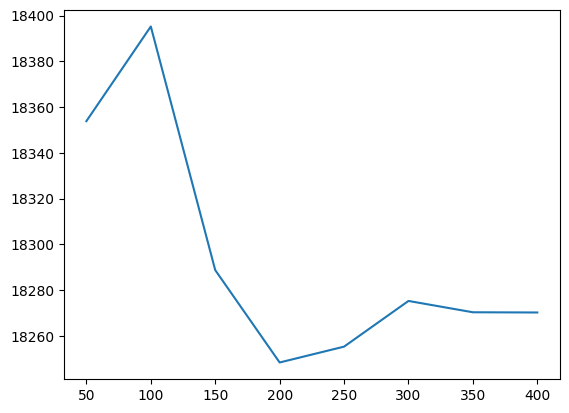

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(list(results.keys()), list(results.values()))
plt.show()

## Step 3: Find the best parameter value

Given the results, which value for `n_estimators` seems best for the random forest model?  Use your answer to set the value of `n_estimators_best`.

In [ ]:
n_estimators_best = 200

# Check your answer
step_3.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [ ]:
# Lines below will give you a hint or solution code
#step_3.hint()
#step_3.solution()

In this exercise, you have explored one method for choosing appropriate parameters in a machine learning model.  

If you'd like to learn more about [hyperparameter optimization](https://en.wikipedia.org/wiki/Hyperparameter_optimization), you're encouraged to start with **grid search**, which is a straightforward method for determining the best _combination_ of parameters for a machine learning model.  Thankfully, scikit-learn also contains a built-in function [`GridSearchCV()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) that can make your grid search code very efficient!


# 6 XGBoost

The most accurate modeling technique for structured data.


In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

home_data_for_ml_course_path = kagglehub.competition_download('home-data-for-ml-course')
dansbecker_aer_credit_card_data_path = kagglehub.dataset_download('dansbecker/aer-credit-card-data')
dansbecker_melbourne_housing_snapshot_path = kagglehub.dataset_download('dansbecker/melbourne-housing-snapshot')

print('Data source import complete.')


In this tutorial, you will learn how to build and optimize models with **gradient boosting**.  This method dominates many Kaggle competitions and achieves state-of-the-art results on a variety of datasets.

## Introduction

For much of this course, you have made predictions with the random forest method, which achieves better performance than a single decision tree simply by averaging the predictions of many decision trees.

We refer to the random forest method as an "ensemble method".  By definition, **ensemble methods** combine the predictions of several models (e.g., several trees, in the case of random forests).  

Next, we'll learn about another ensemble method called gradient boosting.  

## Gradient Boosting

**Gradient boosting** is a method that goes through cycles to iteratively add models into an ensemble.  

It begins by initializing the ensemble with a single model, whose predictions can be pretty naive.  (Even if its predictions are wildly inaccurate, subsequent additions to the ensemble will address those errors.)

Then, we start the cycle:
- First, we use the current ensemble to generate predictions for each observation in the dataset.  To make a prediction, we add the predictions from all models in the ensemble.  
- These predictions are used to calculate a loss function (like [mean squared error](https://en.wikipedia.org/wiki/Mean_squared_error), for instance).
- Then, we use the loss function to fit a new model that will be added to the ensemble.  Specifically, we determine model parameters so that adding this new model to the ensemble will reduce the loss.  (*Side note: The "gradient" in "gradient boosting" refers to the fact that we'll use [gradient descent](https://en.wikipedia.org/wiki/Gradient_descent) on the loss function to determine the parameters in this new model.*)
- Finally, we add the new model to ensemble, and ...
- ... repeat!

![tut6_boosting](https://storage.googleapis.com/kaggle-media/learn/images/MvCGENh.png)


# Example

We begin by loading the training and validation data in `X_train`, `X_valid`, `y_train`, and `y_valid`.

In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split

# Read the data
data = pd.read_csv('../input/melbourne-housing-snapshot/melb_data.csv')

# Select subset of predictors
cols_to_use = ['Rooms', 'Distance', 'Landsize', 'BuildingArea', 'YearBuilt']
X = data[cols_to_use]

# Select target
y = data.Price

# Separate data into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(X, y)

In this example, you'll work with the XGBoost library.  **XGBoost** stands for **extreme gradient boosting**, which is an implementation of gradient boosting with several additional features focused on performance and speed.  (_Scikit-learn has another version of gradient boosting, but XGBoost has some technical advantages._)

In the next code cell, we import the scikit-learn API for XGBoost ([`xgboost.XGBRegressor`](https://xgboost.readthedocs.io/en/latest/python/python_api.html#module-xgboost.sklearn)).  This allows us to build and fit a model just as we would in scikit-learn.  As you'll see in the output, the `XGBRegressor` class has many tunable parameters -- you'll learn about those soon!

In [ ]:
from xgboost import XGBRegressor

my_model = XGBRegressor()
my_model.fit(X_train, y_train)

We also make predictions and evaluate the model.

In [ ]:
from sklearn.metrics import mean_absolute_error

predictions = my_model.predict(X_valid)
print("Mean Absolute Error: " + str(mean_absolute_error(predictions, y_valid)))

## Parameter Tuning

XGBoost has a few parameters that can dramatically affect accuracy and training speed.  The first parameters you should understand are:

### `n_estimators`
`n_estimators` specifies how many times to go through the modeling cycle described above.  It is equal to the number of models that we include in the ensemble.

- Too _low_ a value causes _underfitting_, which leads to inaccurate predictions on both training data and test data.
- Too _high_ a value causes _overfitting_, which causes accurate predictions on training data, but inaccurate predictions on test data (_which is what we care about_).

Typical values range from 100-1000, though this depends a lot on the `learning_rate` parameter discussed below.

Here is the code to set the number of models in the ensemble:

In [ ]:

my_model = XGBRegressor(n_estimators=500)
my_model.fit(X_train, y_train)

### `early_stopping_rounds`

`early_stopping_rounds` offers a way to automatically find the ideal value for `n_estimators`. Early stopping causes the model to stop iterating when the validation score stops improving, even if we aren't at the hard stop for `n_estimators`.  It's smart to set a high value for `n_estimators` and then use `early_stopping_rounds` to find the optimal time to stop iterating.

Since random chance sometimes causes a single round where validation scores don't improve, you need to specify a number for how many rounds of straight deterioration to allow before stopping.  Setting `early_stopping_rounds=5` is a reasonable choice.  In this case, we stop after 5 straight rounds of deteriorating validation scores.

When using `early_stopping_rounds`, you also need to set aside some data for calculating the validation scores - this is done by setting the `eval_set` parameter.  

We can modify the example above to include early stopping:

In [ ]:

my_model = XGBRegressor(n_estimators=500)
my_model.fit(X_train, y_train,
             early_stopping_rounds=5,
             eval_set=[(X_valid, y_valid)],
             verbose=False)

If you later want to fit a model with all of your data, set `n_estimators` to whatever value you found to be optimal when run with early stopping.

### `learning_rate`

Instead of getting predictions by simply adding up the predictions from each component model, we can multiply the predictions from each model by a small number (known as the **learning rate**) before adding them in.  

This means each tree we add to the ensemble helps us less.  So, we can set a higher value for `n_estimators` without overfitting.  If we use early stopping, the appropriate number of trees will be determined automatically.

In general, a small learning rate and large number of estimators will yield more accurate XGBoost models, though it will also take the model longer to train since it does more iterations through the cycle.  As default, XGBoost sets `learning_rate=0.1`.

Modifying the example above to change the learning rate yields the following code:

In [ ]:

my_model = XGBRegressor(n_estimators=1000, learning_rate=0.05)
my_model.fit(X_train, y_train,
             early_stopping_rounds=5,
             eval_set=[(X_valid, y_valid)],
             verbose=False)

### `n_jobs`
On larger datasets where runtime is a consideration, you can use parallelism to build your models faster.  It's common to set the parameter `n_jobs` equal to the number of cores on your machine.  On smaller datasets, this won't help.

The resulting model won't be any better, so micro-optimizing for fitting time is typically nothing but a distraction. But, it's useful in large datasets where you would otherwise spend a long time waiting during the `fit` command.

Here's the modified example:

In [ ]:

my_model = XGBRegressor(n_estimators=1000, learning_rate=0.05, n_jobs=4)
my_model.fit(X_train, y_train,
             early_stopping_rounds=5,
             eval_set=[(X_valid, y_valid)],
             verbose=False)

## Conclusion

[XGBoost](https://xgboost.readthedocs.io/en/latest/) is a leading software library for working with standard tabular data (the type of data you store in Pandas DataFrames, as opposed to more exotic types of data like images and videos).  With careful parameter tuning, you can train highly accurate models.


# 6 Ex XGBoost



In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

home_data_for_ml_course_path = kagglehub.competition_download('home-data-for-ml-course')

print('Data source import complete.')


**This notebook is an exercise in the [Intermediate Machine Learning](https://www.kaggle.com/learn/intermediate-machine-learning) course.  You can reference the tutorial at [this link](https://www.kaggle.com/alexisbcook/xgboost).**

---


In this exercise, you will use your new knowledge to train a model with **gradient boosting**.

## Setup

The questions below will give you feedback on your work. Run the following cell to set up the feedback system.

In [ ]:
# Set up code checking
import os
if not os.path.exists("../input/train.csv"):
    os.symlink("../input/home-data-for-ml-course/train.csv", "../input/train.csv")
    os.symlink("../input/home-data-for-ml-course/test.csv", "../input/test.csv")
from learntools.core import binder
binder.bind(globals())
from learntools.ml_intermediate.ex6 import *
print("Setup Complete")

Setup Complete


You will work with the [Housing Prices Competition for Kaggle Learn Users](https://www.kaggle.com/c/home-data-for-ml-course) dataset from the previous exercise.

![Ames Housing dataset image](https://storage.googleapis.com/kaggle-media/learn/images/lTJVG4e.png)

Run the next code cell without changes to load the training and validation sets in `X_train`, `X_valid`, `y_train`, and `y_valid`.  The test set is loaded in `X_test`.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Read the data
X = pd.read_csv('../input/train.csv', index_col='Id')
X_test_full = pd.read_csv('../input/test.csv', index_col='Id')

# Remove rows with missing target, separate target from predictors
X.dropna(axis=0, subset=['SalePrice'], inplace=True)
y = X.SalePrice
X.drop(['SalePrice'], axis=1, inplace=True)

# Break off validation set from training data
X_train_full, X_valid_full, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2,
                                                                random_state=0)

# "Cardinality" means the number of unique values in a column
# Select categorical columns with relatively low cardinality (convenient but arbitrary)
low_cardinality_cols = [cname for cname in X_train_full.columns if X_train_full[cname].nunique() < 10 and
                        X_train_full[cname].dtype == "object"]

# Select numeric columns
numeric_cols = [cname for cname in X_train_full.columns if X_train_full[cname].dtype in ['int64', 'float64']]

# Keep selected columns only
my_cols = low_cardinality_cols + numeric_cols
X_train = X_train_full[my_cols].copy()
X_valid = X_valid_full[my_cols].copy()
X_test = X_test_full[my_cols].copy()

# One-hot encode the data (to shorten the code, we use pandas)
X_train = pd.get_dummies(X_train)
X_valid = pd.get_dummies(X_valid)
X_test = pd.get_dummies(X_test)
X_train, X_valid = X_train.align(X_valid, join='left', axis=1)
X_train, X_test = X_train.align(X_test, join='left', axis=1)

## Step 1: Build model

### Part A

In this step, you'll build and train your first model with gradient boosting.

- Begin by setting `my_model_1` to an XGBoost model.  Use the [XGBRegressor](https://xgboost.readthedocs.io/en/latest/python/python_api.html#xgboost.XGBRegressor) class, and set the random seed to 0 (`random_state=0`).  **Leave all other parameters as default.**
- Then, fit the model to the training data in `X_train` and `y_train`.

In [ ]:
from xgboost import XGBRegressor

# Define the model
my_model_1 = XGBRegressor(random_state=0)

# Fit the model
my_model_1.fit(X_train, y_train)

# Check your answer
step_1.a.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

### Part B

Set `predictions_1` to the model's predictions for the validation data.  Recall that the validation features are stored in `X_valid`.

In [ ]:
from sklearn.metrics import mean_absolute_error

# Get predictions
predictions_1 = my_model_1.predict(X_valid)

# Check your answer
step_1.b.check()

Mean Absolute Error: 18161.82412510702


<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

### Part C

Finally, use the `mean_absolute_error()` function to calculate the mean absolute error (MAE) corresponding to the predictions for the validation set.  Recall that the labels for the validation data are stored in `y_valid`.

In [ ]:
# Calculate MAE
mae_1 = mean_absolute_error(predictions_1, y_valid)

# Uncomment to print MAE
print("Mean Absolute Error:" , mae_1)

# Check your answer
step_1.c.check()

Mean Absolute Error: 18161.82412510702


<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

## Step 2: Improve the model

Now that you've trained a default model as baseline, it's time to tinker with the parameters, to see if you can get better performance!
- Begin by setting `my_model_2` to an XGBoost model, using the [XGBRegressor](https://xgboost.readthedocs.io/en/latest/python/python_api.html#xgboost.XGBRegressor) class.  Use what you learned in the previous tutorial to figure out how to change the default parameters (like `n_estimators` and `learning_rate`) to get better results.
- Then, fit the model to the training data in `X_train` and `y_train`.
- Set `predictions_2` to the model's predictions for the validation data.  Recall that the validation features are stored in `X_valid`.
- Finally, use the `mean_absolute_error()` function to calculate the mean absolute error (MAE) corresponding to the predictions on the validation set.  Recall that the labels for the validation data are stored in `y_valid`.

In order for this step to be marked correct, your model in `my_model_2` must attain lower MAE than the model in `my_model_1`.

In [ ]:
print("Mean Absolute Error:" , mae_1)
# Define the model
my_model_2 = XGBRegressor(n_estimators=1000, learning_rate=0.05)

# Fit the model
my_model_2.fit(X_train, y_train)

# Get predictions
predictions_2 = my_model_2.predict(X_valid)

# Calculate MAE
mae_2 = mean_absolute_error(predictions_2, y_valid)

# Uncomment to print MAE
print("Mean Absolute Error:" , mae_2)

# Check your answer
step_2.check()

Mean Absolute Error: 18161.82412510702
Mean Absolute Error: 17224.27947078339


<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

## Step 3: Break the model

In this step, you will create a model that performs worse than the original model in Step 1.  This will help you to develop your intuition for how to set parameters.  You might even find that you accidentally get better performance, which is ultimately a nice problem to have and a valuable learning experience!
- Begin by setting `my_model_3` to an XGBoost model, using the [XGBRegressor](https://xgboost.readthedocs.io/en/latest/python/python_api.html#xgboost.XGBRegressor) class.  Use what you learned in the previous tutorial to figure out how to change the default parameters (like `n_estimators` and `learning_rate`) to design a model to get high MAE.
- Then, fit the model to the training data in `X_train` and `y_train`.
- Set `predictions_3` to the model's predictions for the validation data.  Recall that the validation features are stored in `X_valid`.
- Finally, use the `mean_absolute_error()` function to calculate the mean absolute error (MAE) corresponding to the predictions on the validation set.  Recall that the labels for the validation data are stored in `y_valid`.

In order for this step to be marked correct, your model in `my_model_3` must attain higher MAE than the model in `my_model_1`.

In [ ]:
print("Mean Absolute Error:" , mae_1)
print("Mean Absolute Error:" , mae_2)
# Define the model
my_model_3 = XGBRegressor(n_estimators=10, learning_rate=0.05)

# Fit the model
my_model_3.fit(X_train, y_train)

# Get predictions
predictions_3 = my_model_3.predict(X_valid)

# Calculate MAE
mae_3 = mean_absolute_error(predictions_3, y_valid)

# Uncomment to print MAE
print("Mean Absolute Error:" , mae_3)

# Check your answer
step_3.check()

Mean Absolute Error: 18161.82412510702
Mean Absolute Error: 17224.27947078339
Mean Absolute Error: 38339.35846532534


<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>



# 7 Data Leakage

Find and fix this problem that ruins your model in subtle ways.

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

home_data_for_ml_course_path = kagglehub.competition_download('home-data-for-ml-course')
dansbecker_aer_credit_card_data_path = kagglehub.dataset_download('dansbecker/aer-credit-card-data')
dansbecker_melbourne_housing_snapshot_path = kagglehub.dataset_download('dansbecker/melbourne-housing-snapshot')

print('Data source import complete.')


In this tutorial, you will learn what **data leakage** is and how to prevent it. If you don't know how to prevent it, leakage will come up frequently, and it will ruin your models in subtle and dangerous ways.  So, this is one of the most important concepts for practicing data scientists.


## Introduction

**Data leakage** (or **leakage**) happens when your training data contains information about the target, but similar data will not be available when the model is used for prediction. This leads to high performance on the training set (and possibly even the validation data), but the model will perform poorly in production.

In other words, leakage causes a model to look accurate until you start making decisions with the model, and then the model becomes very inaccurate.

There are two main types of leakage: **target leakage** and **train-test contamination.**

### Target leakage

**Target leakage** occurs when your predictors include data that will not be available at the time you make predictions. It is important to think about target leakage in terms of the _timing or chronological order_ that data becomes available, not merely whether a feature helps make good predictions.

An example will be helpful. Imagine you want to predict who will get sick with pneumonia. The top few rows of your raw data look like this:

| got_pneumonia | age | weight |  male | took_antibiotic_medicine | ... |
|:-------------:|:---:|:------:|:-----:|:------------------------:|-----|
|     False     |  65 |   100  | False |           False          | ... |
|     False     |  72 |   130  |  True |           False          | ... |
|      True     |  58 |   100  | False |           True           | ... |

People take antibiotic medicines *after* getting pneumonia in order to recover. The raw data shows a strong relationship between those columns, but `took_antibiotic_medicine` is frequently changed _after_ the value for `got_pneumonia` is determined. This is target leakage.

The model would see that anyone who has a value of `False` for `took_antibiotic_medicine` didn't have pneumonia. Since validation data comes from the same source as training data, the pattern will repeat itself in validation, and the model will have great validation (or cross-validation) scores.

But the model will be very inaccurate when subsequently deployed in the real world, because even patients who will get pneumonia won't have received antibiotics yet when we need to make predictions about their future health.

To prevent this type of data leakage, any variable updated (or created) after the target value is realized should be excluded.

![tut7_leakydata](https://storage.googleapis.com/kaggle-media/learn/images/y7hfTYe.png)

### Train-Test Contamination

A different type of leak occurs when you aren't careful to distinguish training data from validation data.  

Recall that validation is meant to be a measure of how the model does on data that it hasn't considered before.  You can corrupt this process in subtle ways if the validation data affects the preprocessing behavior.  This is sometimes called **train-test contamination**.

For example, imagine you run preprocessing (like fitting an imputer for missing values) before calling [`train_test_split()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).  The end result?  Your model may get good validation scores, giving you great confidence in it, but perform poorly when you deploy it to make decisions.

After all, you incorporated data from the validation or test data into how you make predictions, so the may do well on that particular data even if it can't generalize to new data. This problem becomes even more subtle (and more dangerous) when you do more complex feature engineering.

If your validation is based on a simple train-test split, exclude the validation data from any type of *fitting*, including the fitting of preprocessing steps.  This is easier if you use scikit-learn pipelines.  When using cross-validation, it's even more critical that you do your preprocessing inside the pipeline!

# Example

In this example, you will learn one way to detect and remove target leakage.

We will use a dataset about credit card applications and skip the basic data set-up code.  The end result is that information about each credit card application is stored in a DataFrame `X`.  We'll use it to predict which applications were accepted in a Series `y`.

In [ ]:

import pandas as pd

# Read the data
data = pd.read_csv('../input/aer-credit-card-data/AER_credit_card_data.csv',
                   true_values = ['yes'], false_values = ['no'])

# Select target
y = data.card

# Select predictors
X = data.drop(['card'], axis=1)

print("Number of rows in the dataset:", X.shape[0])
X.head()

Since this is a small dataset, we will use cross-validation to ensure accurate measures of model quality.

In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Since there is no preprocessing, we don't need a pipeline (used anyway as best practice!)
my_pipeline = make_pipeline(RandomForestClassifier(n_estimators=100))
cv_scores = cross_val_score(my_pipeline, X, y,
                            cv=5,
                            scoring='accuracy')

print("Cross-validation accuracy: %f" % cv_scores.mean())

With experience, you'll find that it's very rare to find models that are accurate 98% of the time.  It happens, but it's uncommon enough that we should inspect the data more closely for target leakage.

Here is a summary of the data, which you can also find under the data tab:

 - **`card`**: 1 if credit card application accepted, 0 if not
 - **`reports`**: Number of major derogatory reports
 - **`age`**: Age n years plus twelfths of a year
 - **`income`**: Yearly income (divided by 10,000)
 - **`share`**: Ratio of monthly credit card expenditure to yearly income
 - **`expenditure`**: Average monthly credit card expenditure
 - **`owner`**: 1 if owns home, 0 if rents
 - **`selfempl`**: 1 if self-employed, 0 if not
 - **`dependents`**: 1 + number of dependents
 - **`months`**: Months living at current address
 - **`majorcards`**: Number of major credit cards held
 - **`active`**: Number of active credit accounts

A few variables look suspicious.  For example, does **`expenditure`** mean expenditure on this card or on cards used before applying?

At this point, basic data comparisons can be very helpful:

In [ ]:
expenditures_cardholders = X.expenditure[y]
expenditures_noncardholders = X.expenditure[~y]

print('Fraction of those who did not receive a card and had no expenditures: %.2f' \
      %((expenditures_noncardholders == 0).mean()))
print('Fraction of those who received a card and had no expenditures: %.2f' \
      %(( expenditures_cardholders == 0).mean()))

As shown above, everyone who did not receive a card had no expenditures, while only 2% of those who received a card had no expenditures. It's not surprising that our model appeared to have a high accuracy. But this also seems to be a case of target leakage, where expenditures probably means *expenditures on the card they applied for*.

Since **`share`** is partially determined by **`expenditure`**, it should be excluded too.  The variables **`active`** and **`majorcards`** are a little less clear, but from the description, they sound concerning.  In most situations, it's better to be safe than sorry if you can't track down the people who created the data to find out more.

We would run a model without target leakage as follows:

In [ ]:
# Drop leaky predictors from dataset
potential_leaks = ['expenditure', 'share', 'active', 'majorcards']
X2 = X.drop(potential_leaks, axis=1)

# Evaluate the model with leaky predictors removed
cv_scores = cross_val_score(my_pipeline, X2, y,
                            cv=5,
                            scoring='accuracy')

print("Cross-val accuracy: %f" % cv_scores.mean())

This accuracy is quite a bit lower, which might be disappointing.  However, we can expect it to be right about 80% of the time when used on new applications, whereas the leaky model would likely do much worse than that (in spite of its higher apparent score in cross-validation).

## Conclusion
Data leakage can be multi-million dollar mistake in many data science applications.  Careful separation of training and validation data can prevent train-test contamination, and pipelines can help implement this separation.  Likewise, a combination of caution, common sense, and data exploration can help identify target leakage.




# 7 Data Leakage

Find and fix this problem that ruins your model in subtle ways.

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

home_data_for_ml_course_path = kagglehub.competition_download('home-data-for-ml-course')

print('Data source import complete.')


**This notebook is an exercise in the [Intermediate Machine Learning](https://www.kaggle.com/learn/intermediate-machine-learning) course.  You can reference the tutorial at [this link](https://www.kaggle.com/alexisbcook/data-leakage).**

---


Most people find target leakage very tricky until they've thought about it for a long time.

So, before trying to think about leakage in the housing price example, we'll go through a few examples in other applications. Things will feel more familiar once you come back to a question about house prices.

## Setup

The questions below will give you feedback on your answers. Run the following cell to set up the feedback system.

In [ ]:
# Set up code checking
from learntools.core import binder
binder.bind(globals())
from learntools.ml_intermediate.ex7 import *
print("Setup Complete")

Setup Complete


## Step 1: The Data Science of Shoelaces

Nike has hired you as a data science consultant to help them save money on shoe materials. Your first assignment is to review a model one of their employees built to predict how many shoelaces they'll need each month. The features going into the machine learning model include:
- The current month (January, February, etc)
- Advertising expenditures in the previous month
- Various macroeconomic features (like the unemployment rate) as of the beginning of the current month
- The amount of leather they ended up using in the current month

The results show the model is almost perfectly accurate if you include the feature about how much leather they used. But it is only moderately accurate if you leave that feature out. You realize this is because the amount of leather they use is a perfect indicator of how many shoes they produce, which in turn tells you how many shoelaces they need.

Do you think the _leather used_ feature constitutes a source of data leakage? If your answer is "it depends," what does it depend on?

After you have thought about your answer, check it against the solution below.

In [ ]:
# Check your answer (Run this code cell to receive credit!)
q_1.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 

This is tricky, and it depends on details of how data is collected (which is common when thinking about leakage). Would you at the beginning of the month decide how much leather will be used that month? If so, this is ok. But if that is determined during the month, you would not have access to it when you make the prediction. If you have a guess at the beginning of the month, and it is subsequently changed during the month, the actual amount used during the month cannot be used as a feature (because it causes leakage).

This is tricky, and it depends on details of how data is collected (which is common when thinking about leakage). Would you at the beginning of the month decide how much leather will be used that month? If so, this is ok. But if that is determined during the month, you would not have access to it when you make the prediction. If you have a guess at the beginning of the month, and it is subsequently changed during the month, the actual amount used during the month cannot be used as a feature (because it causes leakage).


## Step 2: Return of the Shoelaces

You have a new idea. You could use the amount of leather Nike ordered (rather than the amount they actually used) leading up to a given month as a predictor in your shoelace model.

Does this change your answer about whether there is a leakage problem? If you answer "it depends," what does it depend on?

In [ ]:
# Check your answer (Run this code cell to receive credit!)
q_2.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 

This could be fine, but it depends on whether they order shoelaces first or leather first. If they order shoelaces first, you won't know how much leather they've ordered when you predict their shoelace needs. If they order leather first, then you'll have that number available when you place your shoelace order, and you should be ok.

This could be fine, but it depends on whether they order shoelaces first or leather first. If they order shoelaces first, you won't know how much leather they've ordered when you predict their shoelace needs. If they order leather first, then you'll have that number available when you place your shoelace order, and you should be ok.

## Step 3: Getting Rich With Cryptocurrencies?

You saved Nike so much money that they gave you a bonus. Congratulations.

Your friend, who is also a data scientist, says he has built a model that will let you turn your bonus into millions of dollars. Specifically, his model predicts the price of a new cryptocurrency (like Bitcoin, but a newer one) one day ahead of the moment of prediction. His plan is to purchase the cryptocurrency whenever the model says the price of the currency (in dollars) is about to go up.

The most important features in his model are:
- Current price of the currency
- Amount of the currency sold in the last 24 hours
- Change in the currency price in the last 24 hours
- Change in the currency price in the last 1 hour
- Number of new tweets in the last 24 hours that mention the currency

The value of the cryptocurrency in dollars has fluctuated up and down by over $\$$100 in the last year, and yet his model's average error is less than $\$$1. He says this is proof his model is accurate, and you should invest with him, buying the currency whenever the model says it is about to go up.

Is he right? If there is a problem with his model, what is it?

In [ ]:
# Check your answer (Run this code cell to receive credit!)
q_3.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 

There is no source of leakage here. These features should be available at the moment you want to make a predition, and they're unlikely to be changed in the training data after the prediction target is determined. But, the way he describes accuracy could be misleading if you aren't careful. If the price moves gradually, today's price will be an accurate predictor of tomorrow's price, but it may not tell you whether it's a good time to invest. For instance, if it is $100 today, a model predicting a price of $100 tomorrow may seem accurate, even if it can't tell you whether the price is going up or down from the current price. A better prediction target would be the change in price over the next day. If you can consistently predict whether the price is about to go up or down (and by how much), you may have a winning investment opportunity.

There is no source of leakage here. These features should be available at the moment you want to make a predition, and they're unlikely to be changed in the training data after the prediction target is determined. But, the way he describes accuracy could be misleading if you aren't careful. If the price moves gradually, today's price will be an accurate predictor of tomorrow's price, but it may not tell you whether it's a good time to invest. For instance, if it is
100 tomorrow may seem accurate, even if it can't tell you whether the price is going up or down from the current price. A better prediction target would be the change in price over the next day. If you can consistently predict whether the price is about to go up or down (and by how much), you may have a winning investment opportunity.

## Step 4: Preventing Infections

An agency that provides healthcare wants to predict which patients from a rare surgery are at risk of infection, so it can alert the nurses to be especially careful when following up with those patients.

You want to build a model. Each row in the modeling dataset will be a single patient who received the surgery, and the prediction target will be whether they got an infection.

Some surgeons may do the procedure in a manner that raises or lowers the risk of infection. But how can you best incorporate the surgeon information into the model?

You have a clever idea.
1. Take all surgeries by each surgeon and calculate the infection rate among those surgeons.
2. For each patient in the data, find out who the surgeon was and plug in that surgeon's average infection rate as a feature.

Does this pose any target leakage issues?
Does it pose any train-test contamination issues?

In [ ]:
# Check your answer (Run this code cell to receive credit!)
q_4.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 

This poses a risk of both target leakage and train-test contamination (though you may be able to avoid both if you are careful).

You have target leakage if a given patient's outcome contributes to the infection rate for his surgeon, which is then plugged back into the prediction model for whether that patient becomes infected. You can avoid target leakage if you calculate the surgeon's infection rate by using only the surgeries before the patient we are predicting for. Calculating this for each surgery in your training data may be a little tricky.

You also have a train-test contamination problem if you calculate this using all surgeries a surgeon performed, including those from the test-set. The result would be that your model could look very accurate on the test set, even if it wouldn't generalize well to new patients after the model is deployed. This would happen because the surgeon-risk feature accounts for data in the test set. Test sets exist to estimate how the model will do when seeing new data. So this contamination defeats the purpose of the test set.

This poses a risk of both target leakage and train-test contamination (though you may be able to avoid both if you are careful).

You have target leakage if a given patient's outcome contributes to the infection rate for his surgeon, which is then plugged back into the prediction model for whether that patient becomes infected. You can avoid target leakage if you calculate the surgeon's infection rate by using only the surgeries before the patient we are predicting for. Calculating this for each surgery in your training data may be a little tricky.

You also have a train-test contamination problem if you calculate this using all surgeries a surgeon performed, including those from the test-set. The result would be that your model could look very accurate on the test set, even if it wouldn't generalize well to new patients after the model is deployed. This would happen because the surgeon-risk feature accounts for data in the test set. Test sets exist to estimate how the model will do when seeing new data. So this contamination defeats the purpose of the test set.

## Step 5: Housing Prices

You will build a model to predict housing prices.  The model will be deployed on an ongoing basis, to predict the price of a new house when a description is added to a website.  Here are four features that could be used as predictors.
1. Size of the house (in square meters)
2. Average sales price of homes in the same neighborhood
3. Latitude and longitude of the house
4. Whether the house has a basement

You have historic data to train and validate the model.

Which of the features is most likely to be a source of leakage?

In [ ]:
# Fill in the line below with one of 1, 2, 3 or 4.
potential_leakage_feature = 2

# Check your answer
q_5.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 

2 is the source of target leakage. Here is an analysis for each feature: 

1. The size of a house is unlikely to be changed after it is sold (though technically it's possible). But typically this will be available when we need to make a prediction, and the data won't be modified after the home is sold. So it is pretty safe. 

2. We don't know the rules for when this is updated. If the field is updated in the raw data after a home was sold, and the home's sale is used to calculate the average, this constitutes a case of target leakage. At an extreme, if only one home is sold in the neighborhood, and it is the home we are trying to predict, then the average will be exactly equal to the value we are trying to predict.  In general, for neighborhoods with few sales, the model will perform very well on the training data.  But when you apply the model, the home you are predicting won't have been sold yet, so this feature won't work the same as it did in the training data. 

3. These don't change, and will be available at the time we want to make a prediction. So there's no risk of target leakage here. 

4. This also doesn't change, and it is available at the time we want to make a prediction. So there's no risk of target leakage here.

2 is the source of target leakage. Here is an analysis for each feature:

The size of a house is unlikely to be changed after it is sold (though technically it's possible). But typically this will be available when we need to make a prediction, and the data won't be modified after the home is sold. So it is pretty safe.

We don't know the rules for when this is updated. If the field is updated in the raw data after a home was sold, and the home's sale is used to calculate the average, this constitutes a case of target leakage. At an extreme, if only one home is sold in the neighborhood, and it is the home we are trying to predict, then the average will be exactly equal to the value we are trying to predict. In general, for neighborhoods with few sales, the model will perform very well on the training data. But when you apply the model, the home you are predicting won't have been sold yet, so this feature won't work the same as it did in the training data.

These don't change, and will be available at the time we want to make a prediction. So there's no risk of target leakage here.

This also doesn't change, and it is available at the time we want to make a prediction. So there's no risk of target leakage here.

## Conclusion
Leakage is a hard and subtle issue. You should be proud if you picked up on the issues in these examples.

Now you have the tools to make highly accurate models, and pick up on the most difficult practical problems that arise with applying these models to solve real problems.

Again, Congratulations!

#